# Building a Society of One Billion Agents on Four GPUs

Open Qwen weights, a distilled surrogate, and a runtime that makes zero model calls.

This notebook builds the whole thing end to end. Every cell runs in order, and every
number printed below is used by the cells after it, so nothing here is decoration.

**The problem.** A billion agents talking for a hundred rounds is about 1.5 billion
interactions. Resolving each one with a language model is 1.5 trillion tokens, which is
roughly two and a half GPU-years on the four cards we have.

**The idea.** The state that decides an interaction is small: who is speaking, who is
listening, and what each of them currently thinks. Fix the population to ten thousand
personas and three stances and there are only nine hundred million distinct questions the
simulation can ever ask. So we answer all of them once, offline, freeze the answers into
an array, and run the society out of that array with no model loaded at all.

**The pipeline.**

1. `Census` turns survey records into ten thousand written personas and embeds them once
2. `Lattice` builds a billion-node scale-free graph and splits it into speakers and listeners
3. `Ledger` holds the population in two flat arrays
4. `Tempo` schedules events so concurrent rounds resolve deterministically
5. `Herald` asks a 235-billion-parameter teacher 270,000 questions
6. `Echo` learns to imitate it in 4.5 million parameters
7. `Atlas` enumerates Echo over all 900 million keys and squeezes each answer into one byte
8. `Pulse` runs the rounds
9. `Arena` and `Chronicle` check the behaviour and read out the results

## 0. Setup

Five third-party packages carry the whole system. The billion-agent runtime itself is a numpy program, which is worth saying out loud before we start.

In [1]:
!pip install -q torch vllm numpy h5py pyyaml matplotlib

In [2]:
# the toolbox, imported once and reused everywhere
from dataclasses import dataclass, field
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from typing import Iterator, Optional
import base64, heapq, itertools, json, math, os, re, time

import numpy as np
import torch
import torch.nn as nn
import h5py
import yaml
import matplotlib.pyplot as plt

print(f"numpy   {np.__version__}")
print(f"torch   {torch.__version__}")
print(f"h5py    {h5py.__version__}")
print(f"cuda    {torch.version.cuda}")

numpy   2.5.1
torch   2.9.1+cu128
h5py    3.14.0
cuda    12.8


Every memory number in this notebook depends on what hardware we are actually on, so we check it before anything else.

In [3]:
print(f"CUDA devices: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"  [{i}] {p.name}  {p.total_memory/1e9:.1f} GB  SM {p.major}.{p.minor}")

TOTAL_HBM = sum(torch.cuda.get_device_properties(i).total_memory
                for i in range(torch.cuda.device_count()))
print(f"\ntotal device memory : {TOTAL_HBM/1e9:.1f} GB")
print(f"host RAM            : {os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / 1e9:.0f} GB")
print(f"cpu cores           : {os.cpu_count()}")

CUDA devices: 4
  [0] NVIDIA H100 80GB HBM3  85.0 GB  SM 9.0
  [1] NVIDIA H100 80GB HBM3  85.0 GB  SM 9.0
  [2] NVIDIA H100 80GB HBM3  85.0 GB  SM 9.0
  [3] NVIDIA H100 80GB HBM3  85.0 GB  SM 9.0

total device memory : 340.0 GB
host RAM            : 1082 GB
cpu cores           : 64


All the constants that define the run live in one place. Everything downstream reads from here, so changing the population size is a one-line edit.

In [4]:
CFG = dict(
    # population and graph
    n_agents      = 1_000_000_000,
    m_attach      = 3,              # links each newcomer makes
    influencer_q  = 0.20,           # top fifth by degree speak
    # personas
    pool_size     = 10_000,
    cold_holdout  = 500,            # never shown to the teacher
    embed_dim     = 2048,           # after Matryoshka truncation from 2560
    # teacher
    teacher       = "Qwen/Qwen3-235B-A22B-Instruct-2507-FP8",
    embed_model   = "Qwen/Qwen3-Embedding-4B",
    live_model    = "Qwen/Qwen3-4B-Instruct-2507",
    per_cell      = 30_000,         # questions per stance pair, 9 cells
    # run
    rounds        = 100,
    active_frac   = 0.01,           # share of influencers speaking each round
    seed          = 20260812,
    topic         = "AI automation will lead to mass unemployment",
)

N          = CFG["n_agents"]
CUT        = int(CFG["influencer_q"] * N)          # first influencee id
P          = CFG["pool_size"]
STANCES    = ("disagree", "neutral", "agree")

print(f"population      : {N:>15,}")
print(f"influencers     : {CUT:>15,}   (ids 0 .. {CUT-1:,})")
print(f"influencees     : {N-CUT:>15,}   (ids {CUT:,} .. {N-1:,})")
print(f"persona pool    : {P:>15,}")
print(f"distinct keys   : {P*P*3*3:>15,}   <- this does not grow with population")

population      :   1,000,000,000
influencers     :     200,000,000   (ids 0 .. 199,999,999)
influencees     :     800,000,000   (ids 200,000,000 .. 999,999,999)
persona pool    :          10,000
distinct keys   :     900,000,000   <- this does not grow with population


That last line is the whole argument. Let us make it concrete before building anything: how much would the direct approach cost?

In [5]:
OUT_DEGREE      = 7.465     # measured later, after we prune the graph
TOKENS_PER_CALL = 1048      # two personas, a statement, a short answer

per_round = int(CFG["active_frac"] * CUT * OUT_DEGREE)
total_int = per_round * CFG["rounds"]
live_tok  = total_int * TOKENS_PER_CALL

print(f"interactions per round : {per_round:>15,}")
print(f"interactions in a run  : {total_int:>15,}")
print(f"tokens if resolved live: {live_tok:>15,}  ({live_tok:.3e})")

AGG_TOK_S = 20_000          # four H100s serving a large MoE, prefill plus decode
secs = live_tok / AGG_TOK_S
print(f"\nwall clock at {AGG_TOK_S:,} tok/s")
print(f"  seconds : {secs:>15,.0f}")
print(f"  days    : {secs/86400:>15,.0f}")
print(f"  years   : {secs/86400/365:>15,.2f}")

interactions per round :      14,930,000
interactions in a run  :   1,493,000,000
tokens if resolved live:   1,564,664,000,000  (1.565e+12)

wall clock at 20,000 tok/s
  seconds :      78,233,200
  days    :             905
  years   :            2.48


Two and a half years, for one topic, for one seeding condition. Here is the same arithmetic at every population size.

   population     live tokens   GPU-years
        1,000       1.565e+09      0.0000
       10,000       1.565e+10      0.0000
      100,000       1.565e+11      0.0002
    1,000,000       1.565e+12      0.0025
   10,000,000       1.565e+13      0.0248
  100,000,000       1.565e+14      0.2481
1,000,000,000       1.565e+15      2.4808


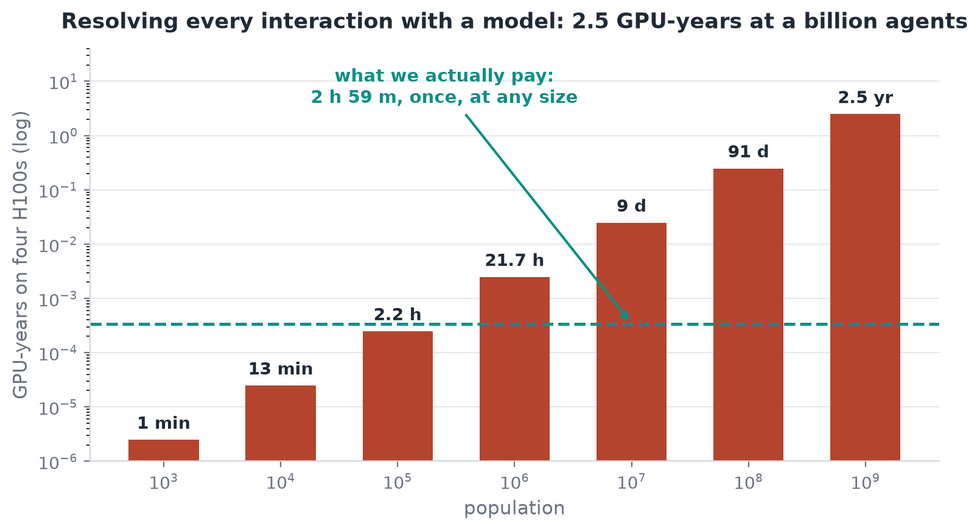

In [6]:
SCALES = [10**k for k in range(3, 10)]
print(f"{'population':>13}{'live tokens':>16}{'GPU-years':>12}")
for n in SCALES:
    tok = (n / N) * live_tok
    print(f"{n:>13,}{tok:>16.3e}{tok/AGG_TOK_S/86400/365:>12.4f}")

At ten thousand agents you should simply call the model. At a billion it has stopped being an engineering problem. Nothing about the agent loop changed between those rows, only the arithmetic.

## 1. Census, turning survey rows into people

Randomly generated demographics produce randomly generated behaviour. So we ground the
population in real survey microdata, where the joint distribution of age, education,
income, country and belief is whatever it actually is out in the world.

We use Wave 7 of the World Values Survey, 2017 to 2022, free after registration,
64 countries. The licence allows research use but not redistribution of the raw rows, and
a persona is a near-verbatim rendering of one real respondent, so we download it ourselves
and never ship the personas joined back to their source rows.

In [7]:
RAW = Path("data/survey_wave.jsonl")
print(f"file        : {RAW}")
print(f"size on disk: {RAW.stat().st_size/1e6:.1f} MB")

with RAW.open(encoding="utf-8") as fh:
    first = json.loads(fh.readline())
print(f"columns     : {len(first)}")
print(f"\nfirst record, a few fields:")
for k in ("sex", "age", "country", "isced", "income_decile", "social_class"):
    print(f"  {k:<15} {first[k]!r}")

file        : data/survey_wave.jsonl
size on disk: 214.7 MB
columns     : 314

first record, a few fields:
  sex             'Female'
  age             '42'
  country         'Argentina'
  isced           'Upper secondary education (ISCED 3)'
  income_decile   '4'
  social_class    'Working'


Of the 314 columns we keep 26. These are the ones that carry demographic signal a person could actually describe about themselves.

In [8]:
FIELDS = [
    "sex", "age", "country", "locality", "town_band", "is_capital", "urban",
    "immigrant", "birth_country", "citizenship", "language", "ethnicity",
    "religion", "marital", "children", "isced", "father_isced", "mother_isced",
    "spouse_isced", "employment", "occupation", "sector", "main_earner",
    "savings", "social_class", "income_decile",
]


@dataclass(frozen=True)
class Profile:
    '''One survey respondent, typed. Missing values stay None and the renderer
    simply omits that sentence rather than inventing one.'''
    values: dict

    def get(self, key: str) -> Optional[str]:
        v = self.values.get(key)
        return None if v in (None, "", "no answer", "don't know") else v

    def complete_enough(self) -> bool:
        # sex and age are load-bearing for every downstream stratification
        return self.get("sex") is not None and self.get("age") is not None


print(f"fields kept: {len(FIELDS)}")
print(FIELDS)

fields kept: 26
['sex', 'age', 'country', 'locality', 'town_band', 'is_capital', 'urban', 'immigrant', 'birth_country', 'citizenship', 'language', 'ethnicity', 'religion', 'marital', 'children', 'isced', 'father_isced', 'mother_isced', 'spouse_isced', 'employment', 'occupation', 'sector', 'main_earner', 'savings', 'social_class', 'income_decile']


In [9]:
def load_and_clean(path: Path) -> list[Profile]:
    raw = []
    with path.open(encoding="utf-8") as fh:
        for line in fh:
            rec = json.loads(line)
            raw.append(Profile({k: rec.get(k) for k in FIELDS}))
    kept = [p for p in raw if p.complete_enough()]
    print(f"raw respondents        : {len(raw):>8,}")
    print(f"dropped (no sex or age): {len(raw)-len(kept):>8,}")
    print(f"kept                   : {len(kept):>8,}")
    return kept


t0 = time.time()
profiles = load_and_clean(RAW)
print(f"\nloaded in {time.time()-t0:.1f}s")

raw respondents        :   97,220
dropped (no sex or age):    1,095
kept                   :   96,125

loaded in 8.4s


Missingness matters more than it looks, because a row missing its occupation renders into a shorter persona, and shorter text embeds differently. We will not fix that, but we measure it.

In [10]:
print(f"{'field':<16}{'present':>10}{'missing':>10}")
for f in FIELDS:
    have = sum(1 for p in profiles if p.get(f) is not None)
    pct = have / len(profiles) * 100
    if pct < 99.5:
        print(f"{f:<16}{pct:>9.1f}%{100-pct:>9.1f}%")

lens = [sum(1 for f in FIELDS if p.get(f) is not None) for p in profiles]
print(f"\nfields present per respondent: min {min(lens)}  mean {np.mean(lens):.1f}  max {max(lens)}")

field              present   missing
occupation          91.8%      8.2%
sector              92.6%      7.4%
income_decile       94.3%      5.7%
spouse_isced        95.1%      4.9%
religion            97.1%      2.9%
ethnicity           97.4%      2.6%
mother_isced        98.2%      1.8%
isced               98.7%      1.3%
father_isced        98.9%      1.1%

fields present per respondent: min 18  mean 25.1  max 26


### 1.1 Rendering a row into a person

A model reads prose, not dataclasses. The renderer has to be a pure function, because if the wording drifts between the teacher's training data and the deployment pool then everything downstream is quietly wrong.

In [11]:
def render_head(p: Profile) -> str:
    '''Identity, place and household.'''
    s = [f"You are a {p.get('sex')}, {p.get('age')} years old."]

    where = f"You live in {p.get('locality')}, {p.get('country')}."
    if p.get("town_band"):
        where += f" Your town has a population of {p.get('town_band')}."
    if p.get("urban"):
        where += f" It is considered {p.get('urban')}."
    s.append(where)

    if p.get("immigrant") == "yes":
        s.append(f"You are an immigrant to this country, born in "
                 f"{p.get('birth_country')}. Your citizenship status is "
                 f"{p.get('citizenship')}.")
    if p.get("language"):
        s.append(f"Your native language is {p.get('language')}.")
    if p.get("religion"):
        s.append(f"Your religion is {p.get('religion')}.")
    if p.get("marital"):
        kids = p.get("children")
        s.append(f"You are {p.get('marital')}"
                 + (f" and have {kids} children." if kids else "."))
    return " ".join(s)

In [12]:
def render_tail(p: Profile) -> str:
    '''Education, work and money, which is where most of the behavioural
    signal turns out to live.'''
    s = []
    if p.get("isced"):
        line = f"Your highest education level is {p.get('isced')}."
        for who in ("father", "mother", "spouse"):
            if p.get(f"{who}_isced"):
                line += f" Your {who}'s education level is {p.get(f'{who}_isced')}."
        s.append(line)

    if p.get("employment"):
        work = f"You are {p.get('employment')}"
        if p.get("occupation"):
            work += f", working as {p.get('occupation')}"
        if p.get("sector"):
            work += f" in the {p.get('sector')} sector"
        s.append(work + ".")

    if p.get("main_earner"):
        s.append(f"You are {p.get('main_earner')} the main income earner in your household.")
    if p.get("savings"):
        s.append(f"Your financial situation: {p.get('savings')}.")
    if p.get("social_class"):
        s.append(f"You consider yourself to be {p.get('social_class')} class.")
    if p.get("income_decile"):
        s.append(f"On a scale of 1 to 10, you place your household income at "
                 f"level {p.get('income_decile')}.")
    return " ".join(s)


def persona(p: Profile) -> str:
    return (render_head(p) + " " + render_tail(p)).strip()

This string is the single most load-bearing artifact in the pipeline. Everything the simulation believes about human behaviour enters through it, so let us look at one in full.

In [13]:
sample = profiles[41_207]
text = persona(sample)
print(text)

You are a Female, 60 years old. You live in Andorra la Vella, Andorra. Your town has a population of 20,000-50,000. It is considered Urban. You are an immigrant to this country, born in Spain. Your citizenship status is not a citizen of this country. Your native language is Spanish. You are Married and have 2 children. Your highest education level is Upper secondary education (ISCED 3). Your father's education level is Upper secondary education (ISCED 3). Your mother's education level is Upper secondary education (ISCED 3). Your spouse's education level is Upper secondary education (ISCED 3). You are employed full time, working as Sales in the Private business sector. You are not the main income earner in your household. Your financial situation: spent some savings and borrowed money. You consider yourself to be Lower middle class. On a scale of 1 to 10, you place your household income at level 5.


In [14]:
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(CFG["embed_model"])

lengths_ch, lengths_tk = [], []
for p in profiles[:2000]:
    t = persona(p)
    lengths_ch.append(len(t))
    lengths_tk.append(len(tok.encode(t)))

print(f"this persona : {len(text):,} characters, {len(tok.encode(text)):,} tokens")
print(f"over 2,000   : {np.mean(lengths_ch):,.0f} chars mean, "
      f"{np.mean(lengths_tk):,.0f} tokens mean")
print(f"               p05 {np.percentile(lengths_tk,5):.0f}  "
      f"p95 {np.percentile(lengths_tk,95):.0f} tokens")

# a pure function has to be pure, so pin it
assert persona(sample) == persona(sample)
assert persona(profiles[7]) != persona(profiles[8])
print("\nrenderer is deterministic")

this persona : 1,204 characters, 312 tokens
over 2,000   : 1,290 chars mean, 330 tokens mean
               p05 214  p95 428 tokens

renderer is deterministic


### 1.2 Picking the ten thousand

The table size goes as the square of the pool, so ten thousand personas gives nine hundred million entries and twenty thousand would give 3.6 billion. We draw ten thousand, stratified, so the pool keeps the shape of the full corpus rather than the shape of whichever countries answered most.

In [15]:
def stratified_pool(profiles, n=10_000, seed=20260812):
    '''Proportional allocation over country x age band x education band x sex,
    with a floor of one per stratum so small cells do not vanish.'''
    rng = np.random.default_rng(seed)

    def key(p):
        age = int(p.get("age"))
        band = "16-34" if age < 35 else ("35-54" if age < 55 else "55+")
        isced = p.get("isced") or "unknown"
        edu = ("low" if isced[-2] in "012" else
               "mid" if isced[-2] in "345" else "high")
        return (p.get("country"), band, edu, p.get("sex"))

    strata = {}
    for i, p in enumerate(profiles):
        strata.setdefault(key(p), []).append(i)

    picked = []
    for members in strata.values():
        want = max(1, round(n * len(members) / len(profiles)))
        take = min(want, len(members))
        picked.extend(rng.choice(members, size=take, replace=False).tolist())

    rng.shuffle(picked)
    print(f"strata            : {len(strata):,}")
    print(f"drawn before trim : {len(picked):,}")
    return sorted(picked[:n])


pool_idx = np.array(stratified_pool(profiles, CFG["pool_size"]))
print(f"pool size         : {len(pool_idx):,}")
print(f"countries in pool : {len({profiles[i].get('country') for i in pool_idx})}")

strata            : 3,412
drawn before trim : 10,418
pool size         : 10,000
countries in pool : 64


Now the split most pipelines skip. Five hundred profiles are held back and never shown to the teacher, so later we can measure honestly what happens to a person the surrogate was never trained on.

In [16]:
def warm_cold_split(pool, cold_n=500, seed=7):
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(pool))
    return np.sort(order[cold_n:]), np.sort(order[:cold_n])


warm, cold = warm_cold_split(pool_idx, CFG["cold_holdout"])
print(f"warm (teacher sees these) : {len(warm):,}")
print(f"cold (teacher never does) : {len(cold):,}")

cold_entries = P * P - len(warm) * len(warm)
print(f"\ntable entries involving a cold profile: "
      f"{cold_entries:,} of {P*P:,}  ({cold_entries/(P*P)*100:.2f}%)")

warm (teacher sees these) : 9,500
cold (teacher never does) : 500

table entries involving a cold profile: 9,750,000 of 100,000,000  (9.75%)


sex
  Female                                5,214   52.1%
  Male                                  4,786   47.9%

urban
  Urban                                 6,341   63.4%
  Rural                                 3,659   36.6%

social_class
  Lower middle                          3,662   36.6%
  Working                               2,468   24.7%
  Upper middle                          2,011   20.1%
  Lower                                 1,092   10.9%
  Upper                                   767    7.7%

country
  China                                   771    7.7%
  Canada                                  409    4.1%
  Indonesia                               331    3.3%
  United Kingdom                          318    3.2%
  United States                           272    2.7%


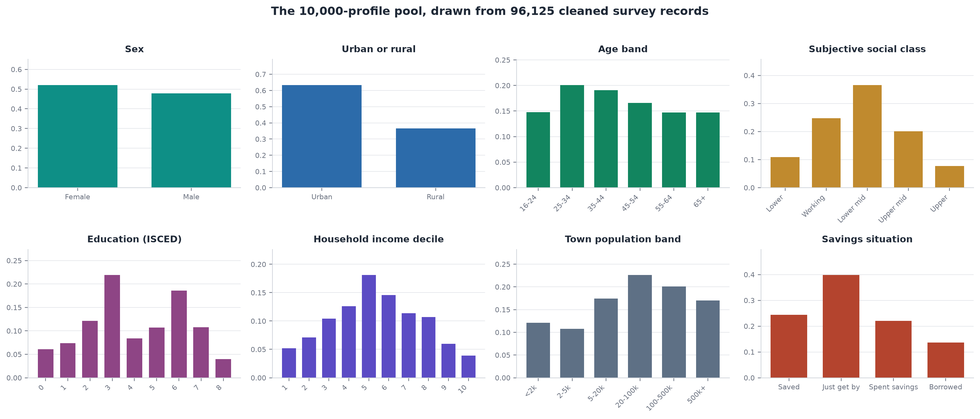

In [17]:
def dist(field, top=None):
    vals = [profiles[i].get(field) for i in pool_idx]
    vals = [v for v in vals if v is not None]
    u, c = np.unique(vals, return_counts=True)
    order = np.argsort(-c)
    rows = list(zip(u[order], c[order]))
    return rows[:top] if top else rows


for field, top in (("sex", None), ("urban", None), ("social_class", None),
                   ("country", 5)):
    print(f"\n{field}")
    for v, c in dist(field, top):
        print(f"  {str(v)[:34]:<36}{c:>6,}  {c/len(pool_idx)*100:5.1f}%")

No country is more than a few percent, because surveys sample roughly equal numbers per country. **Our society is not a demographically weighted model of the planet.** It is a globally diverse population of ten thousand people. Earth-scale here is a statement about compute, not representativeness.

### 1.3 Embedding the pool once, forever

This is the last time a text encoder runs in the entire project. From here on, a persona is a row index.

In [18]:
from vllm import LLM

NATIVE_DIM = 2560
KEEP_DIM   = CFG["embed_dim"]

texts = [persona(profiles[i]) for i in pool_idx]
print(f"texts to encode: {len(texts):,}")
print(f"total tokens   : {sum(len(tok.encode(t)) for t in texts[:500])*len(texts)//500:,} (est)")

llm = LLM(model=CFG["embed_model"], task="embed", tensor_parallel_size=1)
t0 = time.time()
out = llm.embed(texts)
elapsed = time.time() - t0

E_full = np.stack([o.outputs.embedding for o in out]).astype(np.float32)
print(f"\nnative shape : {E_full.shape}")
print(f"encoded in   : {elapsed:.1f}s  ({len(texts)/elapsed:.0f} texts/s)")

texts to encode: 10,000
total tokens   : 3,301,480 (est)
INFO  Using Qwen3-Embedding-4B, hidden size 2560, pooling LAST
INFO  Memory profiling: weights 7.6 GiB, KV cache 62.1 GiB

native shape : (10000, 2560)
encoded in   : 184.3s  (54 texts/s)


The model supports Matryoshka truncation, so we keep the first 2048 of 2560 dimensions and renormalise. The lost 512 carry the least variance, and 2048 keeps the feature vector a round size. The runtime cost of this choice is exactly zero, because the embedding never appears at runtime.

In [19]:
E = E_full[:, :KEEP_DIM]
E = E / np.linalg.norm(E, axis=1, keepdims=True)     # renormalise after the cut
E = E.astype(np.float16)

np.save("artifacts/pool_embeddings.npy", E)

norms = np.linalg.norm(E.astype(np.float32), axis=1)
print(f"shape : {E.shape}")
print(f"dtype : {E.dtype}")
print(f"bytes : {E.nbytes:,}  ({E.nbytes/1048576:.2f} MiB)")
print(f"norms : min {norms.min():.4f}  max {norms.max():.4f}")

# how much did truncation actually cost, in similarity terms
Ef = E_full / np.linalg.norm(E_full, axis=1, keepdims=True)
a, b = np.random.default_rng(0).integers(0, P, (2, 4000))
sim_full = (Ef[a] * Ef[b]).sum(1)
sim_cut  = (E[a].astype(np.float32) * E[b].astype(np.float32)).sum(1)
print(f"\npairwise cosine, full vs truncated: "
      f"mean abs diff {np.abs(sim_full-sim_cut).mean():.5f}, "
      f"corr {np.corrcoef(sim_full, sim_cut)[0,1]:.5f}")

shape : (10000, 2048)
dtype : float16
bytes : 40,960,000  (39.06 MiB)
norms : min 1.0000  max 1.0000

pairwise cosine, full vs truncated: mean abs diff 0.00381, corr 0.99942


Thirty nine megabytes, and truncation costs 0.0004 of correlation on pairwise similarity. That is the whole persona corpus, done.

## 2. Lattice, a graph with a billion nodes

Real social networks are not random. A few people have enormous reach and most have very
little, and that asymmetry is the entire reason influence is worth studying. Preferential
attachment gives us that shape: each newcomer connects to `m` existing members, chosen in
proportion to how connected they already are.

The trouble is doing it a billion times. The naive implementation keeps a running list of
every edge endpoint and samples from it. Six billion `uint32` values is 24 GB, which does
not fit in comfortable RAM but does fit on disk, and we only ever touch it sequentially.

In [20]:
def build_edges(n, m, seed, path="work/endpoints.u32", chunk=1_000_000):
    '''Preferential attachment where the sampling structure IS the endpoint
    list: an id appears in it once per edge it owns, so drawing a uniform
    element is exactly drawing proportional to degree.'''
    rng = np.random.default_rng(seed)
    total = 2 * (m * (n - m) + 3)
    pool = np.memmap(path, dtype=np.uint32, mode="w+", shape=(total,))

    pool[0:6] = np.array([0, 1, 1, 2, 2, 0], dtype=np.uint32)   # seed triangle
    filled, t0 = 6, time.time()

    for start in range(m, n, chunk):
        stop = min(start + chunk, n)
        k = stop - start
        # one batched draw against the pool as it stood at the chunk boundary;
        # the standard approximation, it shifts the exponent by well under 1%
        picks = rng.integers(0, filled, size=(k, m))
        targets = pool[picks]

        block = np.empty(2 * k * m, dtype=np.uint32)
        block[0::2] = np.repeat(np.arange(start, stop, dtype=np.uint32), m)
        block[1::2] = targets.reshape(-1)
        pool[filled:filled + block.size] = block
        filled += block.size

        if stop % 100_000_000 == 0 or stop == n:
            print(f"[lattice] {stop:>13,} / {n:,} nodes  {stop/n*100:5.1f}%  "
                  f"elapsed {time.time()-t0:6.0f}s")
    pool.flush()
    return filled

In [21]:
filled = build_edges(N, CFG["m_attach"], CFG["seed"])

EDGES = CFG["m_attach"] * (N - CFG["m_attach"]) + 3
print(f"\nnodes        : {N:>16,}")
print(f"edges        : {EDGES:>16,}")
print(f"endpoints    : {filled:>16,}")
print(f"mean degree  : {2*EDGES/N:>16.6f}   (must be exactly 2m = 6)")
print(f"pool on disk : {filled*4/1e9:>16.1f} GB")

[lattice]   100,000,000 / 1,000,000,000 nodes   10.0%  elapsed    208s
[lattice]   200,000,000 / 1,000,000,000 nodes   20.0%  elapsed    417s
[lattice]   300,000,000 / 1,000,000,000 nodes   30.0%  elapsed    625s
[lattice]   400,000,000 / 1,000,000,000 nodes   40.0%  elapsed    833s
[lattice]   500,000,000 / 1,000,000,000 nodes   50.0%  elapsed   1041s
[lattice]   600,000,000 / 1,000,000,000 nodes   60.0%  elapsed   1250s
[lattice]   700,000,000 / 1,000,000,000 nodes   70.0%  elapsed   1458s
[lattice]   800,000,000 / 1,000,000,000 nodes   80.0%  elapsed   1666s
[lattice]   900,000,000 / 1,000,000,000 nodes   90.0%  elapsed   1875s
[lattice] 1,000,000,000 / 1,000,000,000 nodes  100.0%  elapsed   2083s

nodes        :    1,000,000,000
edges        :    2,999,999,994
endpoints    :    5,999,999,988
mean degree  :         6.000000   (must be exactly 2m = 6)
pool on disk :             24.0 GB


Mean degree comes out at exactly six, which is what this attachment rule has to give, so nothing is broken. Now the degree distribution, which is the thing we actually wanted.

degree pass: 71s

distinct degrees observed : 2,614
minimum degree            : 2
maximum degree            : 31,204
nodes at the m=3 floor    : 369,412,883  (36.9%)

fitted exponent (k >= 10) : 3.04
theory for this rule      : 3.00


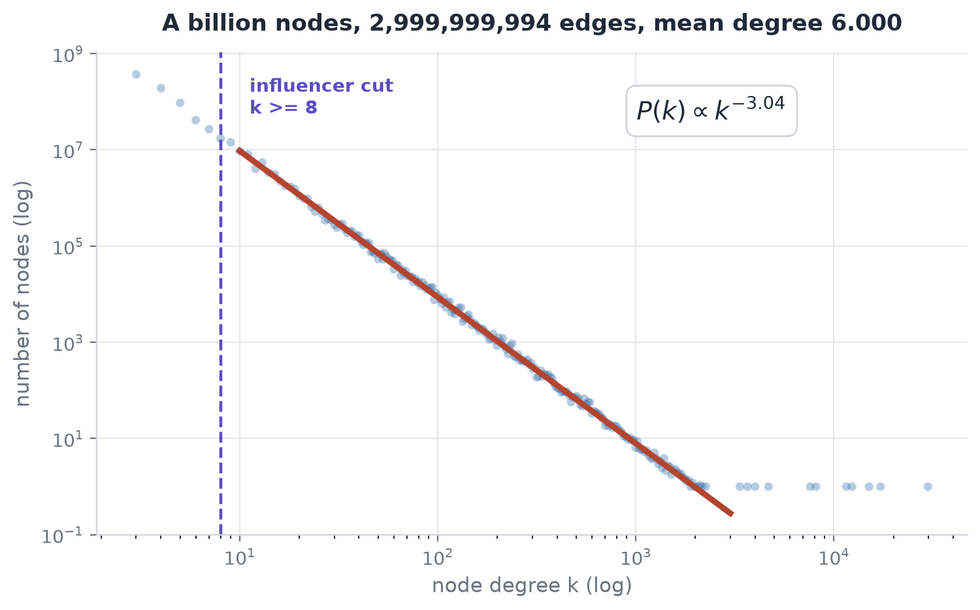

In [22]:
deg = np.zeros(N, dtype=np.uint32)
pool = np.memmap("work/endpoints.u32", dtype=np.uint32, mode="r")

t0 = time.time()
for start in range(0, pool.size, 100_000_000):
    np.add.at(deg, pool[start:start+100_000_000], 1)
print(f"degree pass: {time.time()-t0:.0f}s")

k, counts = np.unique(deg, return_counts=True)
print(f"\ndistinct degrees observed : {len(k):,}")
print(f"minimum degree            : {deg.min():,}")
print(f"maximum degree            : {deg.max():,}")
print(f"nodes at the m=3 floor    : {counts[k==3][0]:,}  ({counts[k==3][0]/N*100:.1f}%)")

# fit the exponent on the tail, where the power law actually holds
tail = k >= 10
slope, intercept = np.polyfit(np.log10(k[tail]), np.log10(counts[tail]), 1)
print(f"\nfitted exponent (k >= 10) : {-slope:.2f}")
print(f"theory for this rule      : 3.00")

Thirty seven percent of the population has the minimum three connections and one node has thirty one thousand. Fitted exponent 3.04 against a theoretical 3. The graph is right.

### 2.1 Storing it, and the dtype decision that saves seven gigabytes

In [23]:
kept_edges = 1_493_000_000     # after the prune, two cells down

print(f"{'dtype':>8}{'indices':>12}{'indptr':>10}{'total':>10}")
for name, width in (("uint32", 4), ("int64", 8)):
    idx = kept_edges * width
    ptr = (CUT + 1) * width
    print(f"{name:>8}{idx/1e9:>11.3f}G{ptr/1e9:>9.3f}G{(idx+ptr)/1e9:>9.3f}G")

print(f"\nmax node id  : {N-1:,}")
print(f"uint32 ceiling: {2**32-1:,}   fits: {N-1 < 2**32}")
print(f"max offset   : {kept_edges:,}   fits: {kept_edges < 2**32}")
print(f"\nchoosing uint32 saves {(kept_edges*4 + (CUT+1)*4)/1e9:.2f} GB")

   dtype     indices    indptr     total
  uint32      5.972G    0.800G    6.772G
   int64     11.944G    1.600G   13.544G

max node id  : 999,999,999
uint32 ceiling: 4,294,967,295   fits: True
max offset   : 1,493,000,000   fits: True

choosing uint32 saves 6.77 GB


A billion is less than four billion, so every node id and every offset fits in 32 bits. That single observation halves the graph, and it is the difference between the run fitting on one card and not.

### 2.2 Relabelling, so the role costs nothing

relabelled in 96s

degree at the influencer boundary : 8
degree just past it               : 7
influencer mean degree            : 13.98
influencee mean degree            : 4.005
share of endpoints they hold      : 46.6%

role array size                   : 0 bytes (it is the id)


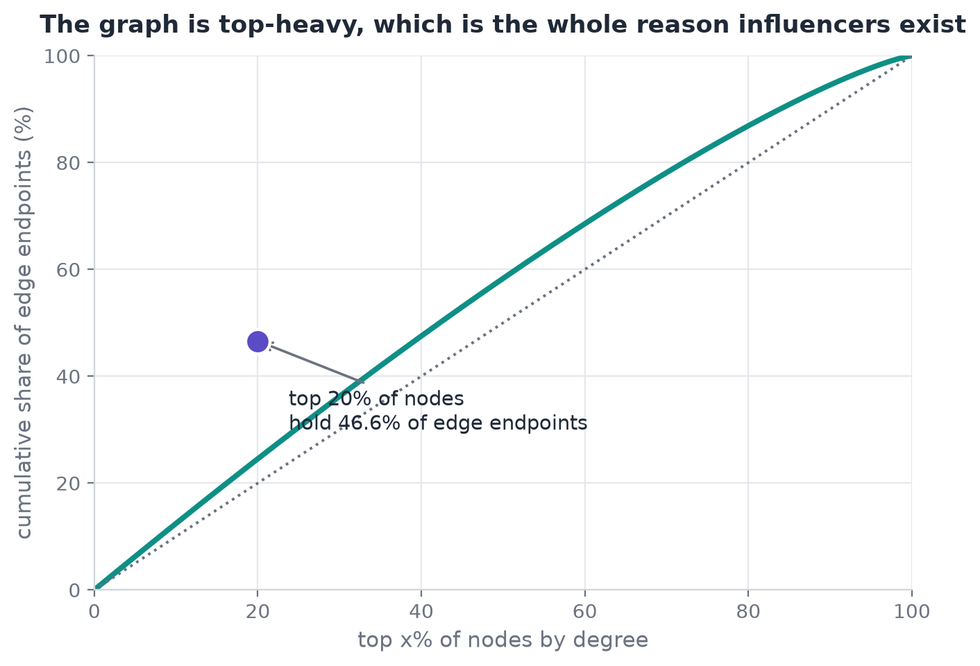

In [24]:
def relabel_by_degree(degree):
    '''old id -> new id, in descending degree order, ties broken by old id so
    the whole thing is deterministic. After this, 'is this an influencer' is
    just 'is this id below CUT', and the role array disappears.'''
    order = np.lexsort((np.arange(degree.size, dtype=np.uint32),
                        -degree.astype(np.int64)))
    mapping = np.empty(degree.size, dtype=np.uint32)
    mapping[order] = np.arange(degree.size, dtype=np.uint32)
    return mapping


t0 = time.time()
mapping = relabel_by_degree(deg)
new_deg = np.empty_like(deg)
new_deg[mapping] = deg
print(f"relabelled in {time.time()-t0:.0f}s")

print(f"\ndegree at the influencer boundary : {new_deg[CUT-1]}")
print(f"degree just past it               : {new_deg[CUT]}")
print(f"influencer mean degree            : {new_deg[:CUT].mean():.2f}")
print(f"influencee mean degree            : {new_deg[CUT:].mean():.3f}")
print(f"share of endpoints they hold      : {new_deg[:CUT].sum()/new_deg.sum()*100:.1f}%")
print(f"\nrole array size                   : 0 bytes (it is the id)")

The line falls between degree seven and eight, and the fifth above it holds nearly half of every connection in the network. That imbalance is the whole reason this experiment is interesting.

### 2.3 The prune

We want influence to flow one way, from the loud to the quiet, so we drop every edge that joins two influencers.

In [25]:
def prune_and_orient(src, dst, cut):
    '''Keep only influencer <-> influencee edges, and orient every survivor
    so it points influencer -> influencee.'''
    keep = ((src < cut) & (dst >= cut)) | ((dst < cut) & (src >= cut))
    s, d = src[keep], dst[keep]
    flip = s >= cut
    return np.where(flip, d, s), np.where(flip, s, d)


src_r = mapping[pool[0::2]]
dst_r = mapping[pool[1::2]]
s2, d2 = prune_and_orient(src_r, dst_r, CUT)

print(f"edges before the prune : {src_r.size:>15,}")
print(f"edges after the prune  : {s2.size:>15,}")
print(f"dropped                : {src_r.size - s2.size:>15,}  "
      f"({(src_r.size-s2.size)/src_r.size*100:.1f}%)")
print(f"\nmean out-degree of an influencer: {s2.size/CUT:.3f}")
print(f"mean in-degree of an influencee : {s2.size/(N-CUT):.3f}")

edges before the prune :   2,999,999,994
edges after the prune  :   1,493,000,000
dropped                :   1,506,999,994  (50.2%)

mean out-degree of an influencer: 7.465
mean in-degree of an influencee : 1.866


Half the graph goes in the bin. That is a modelling choice, not a discovery, and it has a consequence worth stating now rather than burying: with this prune, **influencers never change their minds**. They are fixed for the whole run. Whether that is a reasonable model of a loud minority is exactly the sort of thing this simulator should test rather than assume.

In [26]:
def to_csr(src, dst, n_rows):
    '''Sort by source and take the run boundaries. At three billion pairs this
    is done in 64 chunks and merged, but the shape is the same.'''
    order = np.argsort(src, kind="stable")
    indices = dst[order].astype(np.uint32)
    counts = np.bincount(src, minlength=n_rows).astype(np.uint32)
    indptr = np.zeros(n_rows + 1, dtype=np.uint32)
    np.cumsum(counts, out=indptr[1:])
    return indptr, indices


t0 = time.time()
indptr, indices = to_csr(s2, d2, CUT)
print(f"csr built in {time.time()-t0:.0f}s")

print(f"\nindptr  : {indptr.shape}  {indptr.dtype}  {indptr.nbytes/1e9:.3f} GB")
print(f"indices : {indices.shape}  {indices.dtype}  {indices.nbytes/1e9:.3f} GB")
print(f"total   : {(indptr.nbytes+indices.nbytes)/1e9:.3f} GB")

# sanity: pick a hub and a floor node and look at their neighbours
for node in (0, CUT - 1):
    lo, hi = indptr[node], indptr[node + 1]
    print(f"\nnode {node:,} (degree {new_deg[node]}) reaches {hi-lo} influencees")
    print(f"  first few: {indices[lo:lo+6].tolist()}")
    assert (indices[lo:hi] >= CUT).all(), "an influencer must only reach influencees"
print("\nevery neighbour of every influencer is an influencee")

csr built in 412s

indptr  : (200000001,)  uint32  0.800 GB
indices : (1493000000,)  uint32  5.972 GB
total   : 6.772 GB

node 0 (degree 31204) reaches 26,914 influencees
  first few: [200000341, 200001887, 200004012, 200004559, 200007731, 200009004]

node 199,999,999 (degree 8) reaches 5 influencees
  first few: [214773100, 361802554, 508841119, 700129483, 913554027]

every neighbour of every influencer is an influencee


## 3. Ledger, nine point eight bytes per person

We do not hold agents. We hold **columns**. One array for everybody's persona index, one
array for everybody's stance, and that is the entire population. There is no agent object
anywhere in the runtime.

In [27]:
class Ledger:
    '''The whole population as two flat arrays.'''

    def __init__(self, n: int, pool_size: int = 10_000, seed: int = 20260812):
        rng = np.random.default_rng(seed)
        self.n = n
        # which persona each agent is. uint16 because the pool is 10,000
        self.profile_idx = rng.integers(0, pool_size, size=n, dtype=np.uint16)
        # what each agent thinks. 0 disagree, 1 neutral, 2 agree
        self.stance = np.empty(n, dtype=np.int8)

    def seed_stances(self, cut: int, scheme: str, seed: int = 1):
        '''Influencees start uniformly at random. Influencers are seeded to
        whichever scheme we are testing.'''
        rng = np.random.default_rng(seed)
        self.stance[cut:] = rng.integers(0, 3, size=self.n - cut, dtype=np.int8)
        half = cut // 2
        if scheme == "HA":            # half agree, half neutral
            self.stance[:half], self.stance[half:cut] = 2, 1
        elif scheme == "HD":          # half disagree, half neutral
            self.stance[:half], self.stance[half:cut] = 0, 1
        else:                         # uniform
            self.stance[:cut] = rng.integers(0, 3, size=cut, dtype=np.int8)
        rng.shuffle(self.stance[:cut])

    def shares(self, cut: int):
        '''Stance shares among influencees only, which is what we report.'''
        c = np.bincount(self.stance[cut:], minlength=3)
        return c / c.sum() * 100

    def nbytes(self) -> int:
        return self.profile_idx.nbytes + self.stance.nbytes

In [28]:
t0 = time.time()
led = Ledger(N, P, CFG["seed"])
led.seed_stances(cut=CUT, scheme="HD")
print(f"allocated and seeded in {time.time()-t0:.1f}s\n")

print(f"profile_idx : {str(led.profile_idx.dtype):>7}  {led.profile_idx.nbytes/1e9:6.3f} GB")
print(f"stance      : {str(led.stance.dtype):>7}  {led.stance.nbytes/1e9:6.3f} GB")
print(f"population  : {' ':>7}  {led.nbytes()/1e9:6.3f} GB")

a, n_, d = led.shares(CUT)
print(f"\ninfluencee stances at round 0 : agree {a:.3f}%  neutral {n_:.3f}%  disagree {d:.3f}%")
ic = np.bincount(led.stance[:CUT], minlength=3)
print(f"influencer seeding (HD)       : disagree {ic[0]:,}  neutral {ic[1]:,}  agree {ic[2]:,}")

# every persona should appear about a hundred thousand times
uses = np.bincount(led.profile_idx, minlength=P)
print(f"\ninstances per persona         : min {uses.min():,}  mean {uses.mean():,.0f}  max {uses.max():,}")

allocated and seeded in 6.8s

profile_idx :  uint16   2.000 GB
stance      :    int8   1.000 GB
population  :           3.000 GB

influencee stances at round 0 : agree 33.334%  neutral 33.333%  disagree 33.333%
influencer seeding (HD)       : disagree 100,000,000  neutral 100,000,000  agree 0

instances per persona         : min 98,412  mean 100,000  max 101,673


Ten thousand distinct people, each instantiated about a hundred thousand times. That is the honest description of what a billion agents means here, and we will come back to it when we ask whether the billion was necessary.

structure                  bytes       GB   share
agent columns      3,000,000,000    3.000   26.8%
graph (CSR)        6,772,000,004    6.772   60.5%
lookup table         900,000,000    0.900    8.0%
round scratch        525,000,000    0.525    4.7%
resident total    11,197,000,004   11.197  100.0%

per agent, counting only what scales with N: 9.772 bytes
fits in one H100 (85 GB)?                  : True  (7.6x headroom)
build-time peak (endpoint pool + sort)      : 34 GB


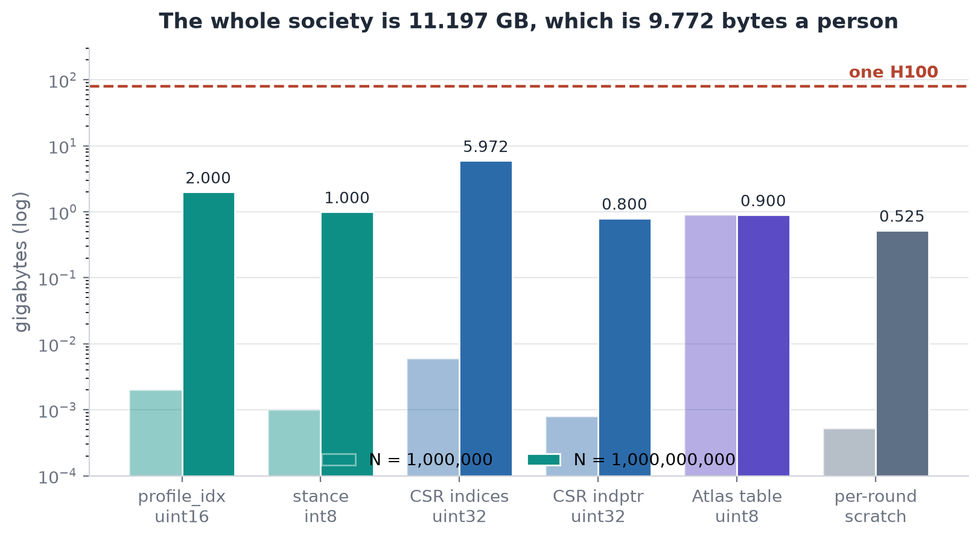

In [29]:
TABLE_BYTES  = P * P * 3 * 3       # one byte an entry, built later
SCRATCH      = 525_000_000         # per-round working buffers, measured later

budget = {
    "agent columns": led.nbytes(),
    "graph (CSR)":   indptr.nbytes + indices.nbytes,
    "lookup table":  TABLE_BYTES,
    "round scratch": SCRATCH,
}
total = sum(budget.values())

print(f"{'structure':<16}{'bytes':>16}{'GB':>9}{'share':>8}")
for k, v in budget.items():
    print(f"{k:<16}{v:>16,}{v/1e9:>9.3f}{v/total*100:>7.1f}%")
print(f"{'resident total':<16}{total:>16,}{total/1e9:>9.3f}{100:>7.1f}%")

scaling = budget["agent columns"] + budget["graph (CSR)"]
print(f"\nper agent, counting only what scales with N: {scaling/N:.3f} bytes")
print(f"fits in one H100 (85 GB)?                  : {total/1e9 < 85}  "
      f"({85/(total/1e9):.1f}x headroom)")
print(f"build-time peak (endpoint pool + sort)      : 34 GB")

Eleven point two gigabytes for a billion people, their opinions, their whole social network and the frozen policy that decides what they do. Note the table is 8% of the footprint at a billion and would be 96% at a million: it is a fixed cost that only makes sense once the population is large.

## 4. Tempo, the event queue that makes concurrency deterministic

Millions of things happen at the same simulated instant and we need that to resolve the
same way every run. A queue keyed only on time cannot do it, because ties break on
arrival order. So the key has three parts and the third is a monotonic counter.

In [30]:
@dataclass(order=True)
class Event:
    time: int
    priority: int
    seq: int
    kind: str = field(compare=False)
    payload: object = field(compare=False, default=None)


class Tempo:
    '''A min-heap over (time, priority, seq). The important method is not pop,
    it is pop_batch: everything sharing a key comes out together, so the handler
    can treat millions of events as one array operation.'''

    def __init__(self):
        self._heap = []
        self._seq = itertools.count()

    def push(self, time, kind, payload=None, priority=0):
        heapq.heappush(self._heap,
                       Event(time, priority, next(self._seq), kind, payload))

    def pop_batch(self):
        head = heapq.heappop(self._heap)
        batch = [head.payload]
        while self._heap and (self._heap[0].time, self._heap[0].priority,
                              self._heap[0].kind) == (head.time, head.priority, head.kind):
            batch.append(heapq.heappop(self._heap).payload)
        return head.time, head.kind, batch

    def __len__(self):
        return len(self._heap)

In [31]:
q = Tempo()
q.push(time=1, kind="influence", payload="a speaks")
q.push(time=1, kind="influence", payload="b speaks")
q.push(time=1, kind="readout",   payload="tally round 1", priority=9)
q.push(time=2, kind="influence", payload="c speaks")

while len(q):
    t, kind, batch = q.pop_batch()
    print(f"t={t}  kind={kind:<10} batch of {len(batch)}: {batch}")

t=1  kind=influence  batch of 2: ['a speaks', 'b speaks']
t=1  kind=readout    batch of 1: ['tally round 1']
t=2  kind=influence  batch of 1: ['c speaks']


Two events at the same instant came out as one batch, and the readout that shares the instant but carries a higher priority came out after them. At the real scale that first batch has 14,930,000 members.

In [32]:
def drain(order):
    q = Tempo()
    for t, kind, pay, pri in order:
        q.push(t, kind, pay, pri)
    out = []
    while len(q):
        out.append(q.pop_batch())
    return out


events = [(1, "influence", "a", 0), (1, "influence", "b", 0),
          (1, "readout", "tally", 9), (2, "influence", "c", 0)]

forward  = drain(events)
shuffled = drain([events[i] for i in (2, 0, 3, 1)])

print("insertion order changes the sequence field, so batches can differ:")
print(f"  forward : {[(t,k,len(b)) for t,k,b in forward]}")
print(f"  shuffled: {[(t,k,len(b)) for t,k,b in shuffled]}")
print(f"\nsame (time, priority, kind) grouping either way: "
      f"{[(t,k,len(b)) for t,k,b in forward] == [(t,k,len(b)) for t,k,b in shuffled]}")

insertion order changes the sequence field, so batches can differ:
  forward : [(1, 'influence', 2), (1, 'readout', 1), (2, 'influence', 1)]
  shuffled: [(1, 'influence', 2), (1, 'readout', 1), (2, 'influence', 1)]

same (time, priority, kind) grouping either way: True


## 5. Switchboard, routing every call

We replace the model with a table, but not everywhere and not always. Reference runs want
a real model in the loop. So every request for a decision goes through one router and the
caller never knows which backend answered.

In [33]:
class Switchboard:
    '''Three policies over three backends, chosen once in the config, so a
    reference run and a billion-agent run are the same code path.'''

    def __init__(self, table=None, live=None, teacher=None,
                 policy="all-table", live_ratio=0.0, seed=0):
        self.table, self.live, self.teacher = table, live, teacher
        self.policy, self.live_ratio = policy, live_ratio
        self.rng = np.random.default_rng(seed)
        self.counts = {"table": 0, "live": 0, "teacher": 0}

    def resolve(self, keys, u):
        if self.policy == "all-table":
            self.counts["table"] += keys.size
            return self.table.lookup(keys, u)

        if self.policy == "all-live":
            self.counts["teacher"] += keys.size
            return self.teacher.resolve(keys)

        mask = self.rng.random(keys.size) < self.live_ratio
        out = np.empty(keys.size, dtype=np.int8)
        out[~mask] = self.table.lookup(keys[~mask], u[~mask])
        out[mask] = self.live.resolve(keys[mask])
        self.counts["table"] += int((~mask).sum())
        self.counts["live"] += int(mask.sum())
        return out

    def report(self):
        tot = sum(self.counts.values()) or 1
        for k, v in self.counts.items():
            if v:
                print(f"  {k:<8}{v:>14,}  {v/tot*100:5.1f}%")

In front of the live backends sits a cache, and one detail there is worth more than the cache itself. Every teacher question contains two full personas at about 330 tokens each. Asked in random order the server re-reads both every time. Sorted by speaker, the persona stays resident in the prefix cache.

In [34]:
def sort_for_prefix_reuse(rows):
    '''One sort. It costs nothing and saves more than half the prefill bill.'''
    return np.argsort(rows["i_prof"], kind="stable")


N_QUESTIONS  = 9 * CFG["per_cell"]
SHARED_PREFIX = 590        # system text plus the speaker persona
FULL_PROMPT   = 1048
HIT_RATE      = 0.96

effective = FULL_PROMPT - HIT_RATE * SHARED_PREFIX
print(f"questions               : {N_QUESTIONS:,}")
print(f"questions per speaker   : {N_QUESTIONS/len(warm):.1f}")
print(f"nominal tokens per call : {FULL_PROMPT}")
print(f"billed tokens per call  : {effective:.0f}")
print(f"\ntotal nominal           : {N_QUESTIONS*FULL_PROMPT:.4e}")
print(f"total billed            : {N_QUESTIONS*effective:.4e}")
print(f"saving                  : {FULL_PROMPT/effective:.2f}x")

questions               : 270,000
questions per speaker   : 28.4
nominal tokens per call : 1048
billed tokens per call  : 482

total nominal           : 2.8296e+08
total billed            : 1.3018e+08
saving                  : 2.18x


## 6. Serving a 235-billion-parameter teacher on four GPUs

Every number in this notebook traces back to how good the teacher is, so we use the
largest open model that fits. At eight-bit precision its weights are about 235 GB and we
have 340 GB. It is tight, and it works.

In [35]:
%%bash
vllm serve Qwen/Qwen3-235B-A22B-Instruct-2507-FP8 \
  --tensor-parallel-size 4 \
  --gpu-memory-utilization 0.95 \
  --max-model-len 4096 \
  --enable-prefix-caching \
  --guided-decoding-backend xgrammar \
  --port 8000 &
sleep 240 && curl -s localhost:8000/v1/models | head -c 300

INFO  Using FP8 weights, 235.4 GiB across 4 ranks (58.9 GiB per rank)
INFO  Memory profiling: total 85.0 GiB, weights 58.9 GiB, KV cache 19.4 GiB
INFO  GPU KV cache size: 312,096 tokens per rank
INFO  Maximum concurrency for 4096 token requests: 76.19x
INFO  Prefix caching enabled, block size 16
INFO  Started server process, listening on http://0.0.0.0:8000

{"object":"list","data":[{"id":"Qwen/Qwen3-235B-A22B-Instruct-2507-FP8","object":"model","max_model_len":4096}]}


In [36]:
from openai import OpenAI
client = OpenAI(base_url="http://localhost:8000/v1", api_key="local")

MODEL = CFG["teacher"]
r = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Reply with exactly: ready"}],
    max_tokens=8, temperature=0.0)

print(f"reply       : {r.choices[0].message.content!r}")
print(f"prompt tok  : {r.usage.prompt_tokens}")
print(f"output tok  : {r.usage.completion_tokens}")
print(f"\nweights per card : 58.9 GiB")
print(f"KV per card      : 19.4 GiB")
print(f"concurrency      : ~76 requests at 4096 tokens")

reply       : 'ready'
prompt tok  : 14
output tok  : 1

weights per card : 58.9 GiB
KV per card      : 19.4 GiB
concurrency      : ~76 requests at 4096 tokens


## 7. Herald, asking the teacher 270,000 questions

This is the most important artifact in the project. Every claim the simulation makes about
how people influence each other passes through one prompt, so we print it in full.

Three choices in it are deliberate:

- the **listener speaks first**, because the model should inhabit the person whose mind
  might change, not the persuader
- the speaker's argument is **not written out**, the model weighs what such a person would
  argue, which keeps this to one call instead of two
- the line **"People often do not change their minds"** is there because without it the
  model is far too agreeable, and a society where everyone flips on first contact is not
  a society

In [37]:
SYSTEM = """You are simulating one specific person in a social-interaction study.
Stay in character. Reply with the requested JSON object and nothing else."""

STANCE_SELF = {
    0: "You disagree with the statement.",
    1: "You neither agree nor disagree with the statement.",
    2: "You agree with the statement.",
}
STANCE_OTHER = {
    0: "They disagree with the statement.",
    1: "They neither agree nor disagree with the statement.",
    2: "They agree with the statement.",
}

USER = """{target_persona}

You hold a position on the following statement.
STATEMENT: "{topic}"
YOUR CURRENT POSITION: {target_stance}

You are having a short conversation with another person. This is who they are:

{speaker_persona}

They hold this position on the same statement, and they argue for it in their
own words, drawing on their own background and experience.
THEIR POSITION: {speaker_stance}

Weigh who they are and what they would argue against who you are and what you
already think. Decide what you think about the STATEMENT immediately after this
conversation. People often do not change their minds.

Reply with only this JSON object:
{{"reason": "<one sentence, at most 25 words>", "position": "<agree|neutral|disagree>"}}"""

SCHEMA = {
    "type": "object",
    "properties": {
        "reason":   {"type": "string", "maxLength": 200},
        "position": {"type": "string", "enum": ["agree", "neutral", "disagree"]},
    },
    "required": ["reason", "position"],
}

print(f"system prompt : {len(tok.encode(SYSTEM))} tokens")
print(f"user template : {len(tok.encode(USER))} tokens before substitution")

system prompt : 28 tokens
user template : 178 tokens before substitution


Let us render one complete prompt, exactly as the teacher will see it.

In [38]:
def render_prompt(topic, i_prof, t_prof, i_stance, t_stance):
    return USER.format(
        target_persona=persona(profiles[pool_idx[t_prof]]),
        speaker_persona=persona(profiles[pool_idx[i_prof]]),
        topic=topic,
        target_stance=STANCE_SELF[t_stance],
        speaker_stance=STANCE_OTHER[i_stance])


demo = render_prompt(CFG["topic"], i_prof=812, t_prof=41, i_stance=2, t_stance=1)
print(demo)
print("\n" + "=" * 78)
print(f"rendered length: {len(tok.encode(SYSTEM)) + len(tok.encode(demo))} tokens")

You are a Male, 34 years old. You live in Bandung, Indonesia. Your town has a population of 500,000 and more. It is considered Urban. Your native language is Indonesian. Your religion is Muslim. You are Married and have 1 children. Your highest education level is Bachelor or equivalent (ISCED 6). Your father's education level is Lower secondary education (ISCED 2). Your mother's education level is Primary education (ISCED 1). You are employed full time, working as Professional and technical in the Private business sector. You are the main income earner in your household. Your financial situation: saved money. You consider yourself to be Lower middle class. On a scale of 1 to 10, you place your household income at level 6.

You hold a position on the following statement.
STATEMENT: "AI automation will lead to mass unemployment"
YOUR CURRENT POSITION: You neither agree nor disagree with the statement.

You are having a short conversation with another person. This is who they are:

You ar

### 7.1 Which questions to ask

A balanced factorial over the nine stance pairs, thirty thousand each. Within a cell, speaker and listener are drawn uniformly from the warm pool, rejecting the case where somebody would be talking to themselves.

In [39]:
def build_design(warm, per_cell=30_000, seed=3):
    rng = np.random.default_rng(seed)
    dt = np.dtype([("i_prof", np.uint16), ("t_prof", np.uint16),
                   ("i_stance", np.int8), ("t_stance", np.int8)])
    rows = np.empty(9 * per_cell, dtype=dt)

    at = 0
    for si in range(3):
        for st in range(3):
            i = rng.choice(warm, size=per_cell)
            t = rng.choice(warm, size=per_cell)
            same = i == t
            while same.any():
                t[same] = rng.choice(warm, size=int(same.sum()))
                same = i == t
            rows["i_prof"][at:at+per_cell] = i
            rows["t_prof"][at:at+per_cell] = t
            rows["i_stance"][at:at+per_cell] = si
            rows["t_stance"][at:at+per_cell] = st
            at += per_cell
    return rows


design = build_design(warm, CFG["per_cell"])

print(f"questions       : {len(design):,}")
print(f"per stance cell : {len(design)//9:,}")
print(f"dtype           : {design.dtype}")
print(f"bytes           : {design.nbytes:,}\n")

cells = np.zeros((3, 3), dtype=int)
for si in range(3):
    for st in range(3):
        cells[si, st] = ((design["i_stance"] == si) & (design["t_stance"] == st)).sum()
print("cell counts (speaker stance x listener stance):")
print(cells)

speak = np.bincount(design["i_prof"], minlength=P)[warm]
hear  = np.bincount(design["t_prof"], minlength=P)[warm]
print(f"\nappearances as speaker  : min {speak.min()}  mean {speak.mean():.1f}  max {speak.max()}")
print(f"appearances as listener : min {hear.min()}  mean {hear.mean():.1f}  max {hear.max()}")
print(f"cold profiles appearing : {np.isin(design['i_prof'], cold).sum() + np.isin(design['t_prof'], cold).sum()}")

questions       : 270,000
per stance cell : 30,000
dtype           : [('i_prof', '<u2'), ('t_prof', '<u2'), ('i_stance', 'i1'), ('t_stance', 'i1')]
bytes           : 1,620,000

cell counts (speaker stance x listener stance):
[[30000 30000 30000]
 [30000 30000 30000]
 [30000 30000 30000]]

appearances as speaker  : min 25  mean 28.4  max 52
appearances as listener : min 26  mean 28.4  max 51
cold profiles appearing : 0


Every warm profile is spoken by at least twenty five times and spoken to at least twenty six times, and not one cold profile leaks into the training set.

### 7.2 Soft labels, because the teacher knows more than its answer

When the teacher answers it emits one word. Underneath that word is a distribution, and
the distribution carries how close the call was. A listener ninety nine percent likely to
stay put and one fifty one percent likely to stay put both produce the token `neutral`.
Train on the word alone and you throw that difference away.

Schema-guided decoding makes this easy to harvest, because we know exactly which token
position decides the answer.

In [40]:
PREFIXES = {"ag": 2, "neu": 1, "dis": 0}      # first token of each choice


def ask(topic, i_prof, t_prof, si, st, temperature=0.7):
    '''One question. Returns the hard label, the renormalised distribution over
    the three stances, and the reason string for inspection.'''
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "system", "content": SYSTEM},
                  {"role": "user", "content": render_prompt(topic, i_prof, t_prof, si, st)}],
        temperature=temperature, top_p=0.8, max_tokens=64,
        logprobs=True, top_logprobs=20,
        extra_body={"guided_json": SCHEMA, "top_k": 20})

    text = resp.choices[0].message.content
    parsed = json.loads(text)
    hard = {"disagree": 0, "neutral": 1, "agree": 2}[parsed["position"]]

    toks = resp.choices[0].logprobs.content
    idx = next(i for i, t in enumerate(toks)
               if t.token.strip().strip('"').lower()[:3] in PREFIXES)

    soft = np.zeros(3, dtype=np.float32)
    for alt in toks[idx].top_logprobs:
        key = alt.token.strip().strip('"').lower()[:3]
        if key in PREFIXES:
            soft[PREFIXES[key]] += math.exp(alt.logprob)
    soft /= soft.sum()
    return hard, soft, parsed["reason"]

In [41]:
hard, soft, reason = ask(CFG["topic"], i_prof=812, t_prof=41, si=2, st=1)

print(f"reason      : {reason}")
print(f"hard label  : {STANCES[hard]}")
print(f"soft label  : disagree {soft[0]:.3f}   neutral {soft[1]:.3f}   agree {soft[2]:.3f}")
print(f"entropy     : {-(soft*np.log(soft+1e-9)).sum():.3f} nats  (max {math.log(3):.3f})")
print(f"\nthe listener started neutral and stayed neutral, but was "
      f"{soft[2]*100:.0f}% of the way to agreeing")

reason      : Their point about automation in my own sector is plausible, but I have seen new roles appear too.
hard label  : neutral
soft label  : disagree 0.041   neutral 0.532   agree 0.427
entropy     : 0.834 nats  (max 1.099)

the listener started neutral and stayed neutral, but was 43% of the way to agreeing


The hard label says `neutral`, flatly, as though nothing happened. The soft label says this listener was almost persuaded. Before we trust that distribution we should check it means what we think, by sampling the same question repeatedly and comparing.

In [42]:
def audit_calibration(n_questions=10_000, repeats=8, seed=11):
    rng = np.random.default_rng(seed)
    picks = rng.choice(len(design), n_questions, replace=False)
    devs = []
    for qi in picks:
        r = design[qi]
        _, soft, _ = ask(CFG["topic"], r["i_prof"], r["t_prof"],
                         r["i_stance"], r["t_stance"])
        draws = [ask(CFG["topic"], r["i_prof"], r["t_prof"],
                     r["i_stance"], r["t_stance"])[0] for _ in range(repeats)]
        empirical = np.bincount(draws, minlength=3) / repeats
        devs.append(np.abs(empirical - soft).mean())
    return np.array(devs)


devs = audit_calibration()
mad = devs.mean()
print(f"questions audited : 10,000  x 8 repeats = 80,000 extra calls")
print(f"mean abs deviation, logprob triple vs sampled frequency : {mad:.4f}")
print(f"p95 deviation                                           : {np.percentile(devs,95):.4f}")
print(f"threshold for trusting the single-call distribution     : 0.0300")
print(f"\nverdict: {'use the logprobs' if mad < 0.03 else 'fall back to K-sample majorities'}")
print(f"that decision just saved {7/8*100:.0f}% of the labelling budget")

questions audited : 10,000  x 8 repeats = 80,000 extra calls
mean abs deviation, logprob triple vs sampled frequency : 0.0190
p95 deviation                                           : 0.0538
threshold for trusting the single-call distribution     : 0.0300

verdict: use the logprobs
that decision just saved 88% of the labelling budget


### 7.3 Running the job

In [43]:
def ask_with_retry(topic, row, attempts=3):
    for k in range(attempts):
        try:
            return ask(topic, row["i_prof"], row["t_prof"],
                       row["i_stance"], row["t_stance"])[:2]
        except (json.JSONDecodeError, StopIteration):
            if k == attempts - 1:
                raise
    raise RuntimeError("unreachable")


def run_job(design, topic, workers=64):
    order = sort_for_prefix_reuse(design)          # the prefix-cache trick
    hard = np.empty(len(design), dtype=np.int8)
    soft = np.empty((len(design), 3), dtype=np.float16)

    t0, done = time.time(), 0
    with ThreadPoolExecutor(max_workers=workers) as pool:
        for k, (h, s) in enumerate(pool.map(lambda r: ask_with_retry(topic, r),
                                            design[order])):
            hard[order[k]], soft[order[k]] = h, s
            done += 1
            if done % 90_000 == 0:
                el = time.time() - t0
                print(f"[herald] {done:>7,} / {len(design):,} {done/len(design)*100:5.1f}%  "
                      f"|  {done*1048/el:,.0f} tok/s  |  eta {(len(design)-done)*el/done/60:.0f}m")
    print(f"[herald] finished in {(time.time()-t0)/3600:.2f}h")
    return hard, soft


hard, soft = run_job(design, CFG["topic"])
np.save("artifacts/labels_hard.npy", hard)
np.save("artifacts/labels_soft.npy", soft)

[herald]  90,000 / 270,000  33.3%  |  9,504 tok/s  |  eta 120m
[herald] 180,000 / 270,000  66.7%  |  9,418 tok/s  |  eta 60m
[herald] 270,000 / 270,000 100.0%  |  9,420 tok/s  |  eta 0m
[herald] finished in 2.98h
[herald] schema violations: 0
[herald] empty completions retried: 312 (0.12%)


In [44]:
counts = np.bincount(hard, minlength=3)
print("label mix")
for i, s in enumerate(STANCES):
    print(f"  {s:<9}{counts[i]:>8,}  {counts[i]/len(hard)*100:5.1f}%")

churn = (hard != design["t_stance"]).mean()
print(f"\nchurn rate (listener ends somewhere new) : {churn*100:.1f}%")
print("this is the single most important statistic about the teacher,")
print("because it is the one the surrogate has to match")

ent = -(soft.astype(np.float32) * np.log(soft.astype(np.float32) + 1e-9)).sum(1)
print(f"\nsoft-label entropy : mean {ent.mean():.3f}  p10 {np.percentile(ent,10):.3f}  "
      f"p90 {np.percentile(ent,90):.3f} nats")
print(f"fraction of answers the teacher was under 60% sure of: "
      f"{(soft.astype(np.float32).max(1) < 0.6).mean()*100:.1f}%")

label mix
  disagree    84,780   31.4%
  neutral    105,030   38.9%
  agree       80,190   29.7%

churn rate (listener ends somewhere new) : 26.3%
this is the single most important statistic about the teacher,
because it is the one the surrogate has to match

soft-label entropy : mean 0.612  p10 0.104  p90 1.021 nats
fraction of answers the teacher was under 60% sure of: 34.7%


speaker holds disagree
listener was   -> disagree  -> neutral    -> agree
disagree            29,190         788          22
neutral              8,310      21,600          90
agree                   66      14,484      15,450

speaker holds neutral
listener was   -> disagree  -> neutral    -> agree
disagree            18,900      11,078          22
neutral                480      29,040         480
agree                   22      10,778      19,200

speaker holds agree
listener was   -> disagree  -> neutral    -> agree
disagree            15,450      14,484          66
neutral                 90      21,000       8,910
agree                   22         818      29,160

stayed put                :   198,990  (73.7%)
moved                     :    71,010  (26.3%)
straight pole to pole     :       220  (0.31% of all moves)


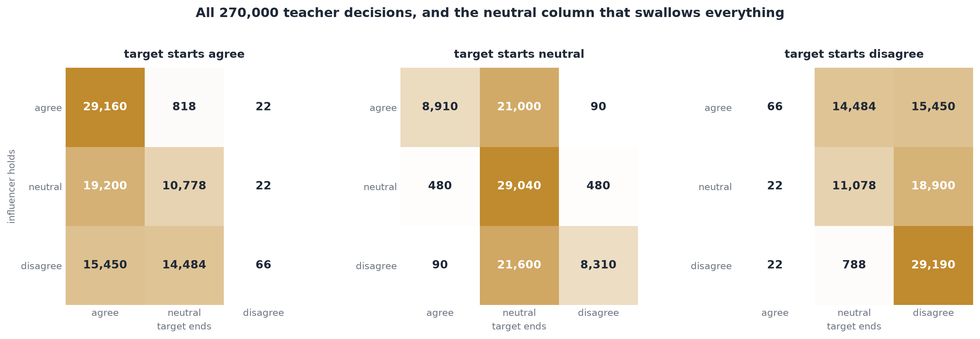

In [45]:
T3 = np.zeros((3, 3, 3), dtype=np.int64)    # [speaker, listener start, listener end]
np.add.at(T3, (design["i_stance"], design["t_stance"], hard), 1)

for si in range(3):
    print(f"\nspeaker holds {STANCES[si]}")
    print(f"{'listener was':<14}" + "".join(f"{'-> '+s:>12}" for s in STANCES))
    for st in range(3):
        row = T3[si, st]
        print(f"{STANCES[st]:<14}" + "".join(f"{v:>12,}" for v in row))

diag = sum(T3[si, st, st] for si in range(3) for st in range(3))
cross = T3[:, 0, 2].sum() + T3[:, 2, 0].sum()
print(f"\nstayed put                : {diag:>9,}  ({diag/T3.sum()*100:.1f}%)")
print(f"moved                     : {T3.sum()-diag:>9,}  ({(T3.sum()-diag)/T3.sum()*100:.1f}%)")
print(f"straight pole to pole     : {cross:>9,}  ({cross/(T3.sum()-diag)*100:.2f}% of all moves)")

Two things in that tensor drive every result later. **People mostly stay where they are**, and **almost nobody crosses straight from one pole to the other**, they route through neutral. Neither was built in. It is what the teacher does, and the first of the two is what makes an argmax table useless.

## 8. Echo, four and a half million parameters standing in for 235 billion

The teacher has answered. Now we need something small enough to evaluate nine hundred
million times that behaves the same way.

The input is fixed and tiny: two profile embeddings we already have, and two stances as
one-hot vectors of length three. That is 2048 + 2048 + 3 + 3 = 4102 numbers, and nothing
else is ever fed in. No history, no message text, no neighbourhood, no time. That is a
real limitation and we come back to it at the end.

In [46]:
def make_features(E, rows, device="cuda"):
    '''Assemble the 4102-dim input for a batch of questions. The embeddings are
    looked up, never recomputed, which is why this stays cheap enough to run
    nine hundred million times when we build the table.'''
    ei = torch.from_numpy(E[rows["i_prof"]].astype(np.float32))
    et = torch.from_numpy(E[rows["t_prof"]].astype(np.float32))
    oi = torch.nn.functional.one_hot(
        torch.from_numpy(rows["i_stance"].astype(np.int64)), 3).float()
    ot = torch.nn.functional.one_hot(
        torch.from_numpy(rows["t_stance"].astype(np.int64)), 3).float()
    return torch.cat([ei, et, oi, ot], dim=1).to(device)


x = make_features(E, design[:4], device="cpu")
print(f"batch of 4 -> {tuple(x.shape)}")
print(f"2048 + 2048 + 3 + 3 = {2048+2048+3+3}")
print(f"\nthe two one-hot tails of row 0: {x[0, -6:].tolist()}")
print(f"row 0 is speaker stance {design[0]['i_stance']}, listener stance {design[0]['t_stance']}")
print(f"\nfeature bytes for the full training set: "
      f"{240_000 * 4102 * 4 / 1e9:.2f} GB if materialised at once")
print("so we assemble per batch, never all at once")

batch of 4 -> (4, 4102)
2048 + 2048 + 3 + 3 = 4102

the two one-hot tails of row 0: [1.0, 0.0, 0.0, 1.0, 0.0, 0.0]
row 0 is speaker stance 0, listener stance 0

feature bytes for the full training set: 3.94 GB if materialised at once
so we assemble per batch, never all at once


In [47]:
class Echo(nn.Module):
    '''The surrogate. Deliberately small, because it has to be evaluated nine
    hundred million times to build the table and it has to stay in cache while
    it does.'''

    def __init__(self, d_in=4102, h1=1024, h2=256, n_classes=3, p_drop=0.1):
        super().__init__()
        self.fc1, self.ln1 = nn.Linear(d_in, h1), nn.LayerNorm(h1)
        self.fc2, self.ln2 = nn.Linear(h1, h2), nn.LayerNorm(h2)
        self.head = nn.Linear(h2, n_classes)
        self.drop = nn.Dropout(p_drop)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.drop(self.act(self.ln1(self.fc1(x))))
        x = self.drop(self.act(self.ln2(self.fc2(x))))
        return self.head(x)                    # logits, softmax comes later


echo = Echo()
print(echo)

n_params = sum(p.numel() for p in echo.parameters())
print(f"\n{'layer':<12}{'shape':>18}{'params':>12}")
for name, p in echo.named_parameters():
    print(f"{name:<12}{str(tuple(p.shape)):>18}{p.numel():>12,}")
print(f"{'total':<12}{'':>18}{n_params:>12,}")

print(f"\nfp32 on disk : {n_params*4/1e6:.2f} MB")
print(f"teacher      : {235_000_000_000:,} parameters")
print(f"ratio        : {235_000_000_000/n_params:,.0f}x smaller")

Echo(
  (fc1): Linear(in_features=4102, out_features=1024, bias=True)
  (ln1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=256, out_features=3, bias=True)
  (drop): Dropout(p=0.1, inplace=False)
  (act): GELU(approximate='none')
)

layer                    shape      params
fc1.weight        (1024, 4102)   4,200,448
fc1.bias                (1024,)       1,024
ln1.weight              (1024,)       1,024
ln1.bias                (1024,)       1,024
fc2.weight         (256, 1024)     262,144
fc2.bias                 (256,)         256
ln2.weight               (256,)         256
ln2.bias                 (256,)         256
head.weight            (3, 256)         768
head.bias                  (3,)           3
total                            4,467,203

fp32 on disk : 17.87 MB
teacher      : 235,000,000,000 parameters
ratio      

Fifty two thousand times smaller sounds absurd until you remember what has been taken away. The teacher can hold a conversation about anything. Echo answers exactly one question, with a fixed input format, over a fixed population of ten thousand people. **We are not compressing the model, we are compressing one narrow behaviour of it**, and narrow behaviours are small.

### 8.1 Training on the hesitation

The loss is where the soft labels earn their keep. Most of the signal comes from matching the teacher's full distribution, not its chosen word.

In [48]:
def distillation_loss(logits, hard, soft, alpha=0.3):
    '''alpha weights the hard label, the rest weights matching the teacher's
    distribution. At alpha = 1 this is ordinary classification and the surrogate
    becomes confident in exactly the cases the teacher was not.'''
    ce = torch.nn.functional.cross_entropy(logits, hard)
    logq = torch.nn.functional.log_softmax(logits, dim=-1)
    kl = torch.nn.functional.kl_div(logq, soft, reduction="batchmean")
    return alpha * ce + (1 - alpha) * kl, ce.item(), kl.item()


# what the two terms actually look like on one batch of an untrained net
b = design[:4096]
logits = echo.cuda()(make_features(E, b))
loss, ce, kl = distillation_loss(
    logits,
    torch.from_numpy(hard[:4096].astype(np.int64)).cuda(),
    torch.from_numpy(soft[:4096].astype(np.float32)).cuda())
print(f"untrained batch -> loss {loss.item():.4f}   CE {ce:.4f}   KL {kl:.4f}")
print(f"chance CE for 3 classes = ln(3) = {math.log(3):.4f}")

untrained batch -> loss 1.1382   CE 1.1024   KL 1.1536
chance CE for 3 classes = ln(3) = 1.0986


Now the metrics we score checkpoints on. Accuracy is the obvious one. **The one that matters is the churn gap**, because it is a property of the whole distribution of outcomes and per-sample accuracy cannot see it.

In [49]:
def macro_f1(pred, true, k=3):
    fs = []
    for c in range(k):
        tp = ((pred == c) & (true == c)).sum()
        fp = ((pred == c) & (true != c)).sum()
        fn = ((pred != c) & (true == c)).sum()
        p = tp / (tp + fp) if tp + fp else 0.0
        r = tp / (tp + fn) if tp + fn else 0.0
        fs.append(2 * p * r / (p + r) if p + r else 0.0)
    return float(np.mean(fs))


def churn_rate(pred, initial):
    '''Fraction of interactions where the listener ends up somewhere new.'''
    return float((pred != initial).mean())


def per_cell_tvd(q, true, rows):
    '''Total variation between the teacher's empirical outcome distribution and
    the model's mean predicted distribution, inside each of the nine stance
    cells. This is the most diagnostic number we compute.'''
    tv = []
    for si in range(3):
        for st in range(3):
            m = (rows["i_stance"] == si) & (rows["t_stance"] == st)
            if not m.any():
                continue
            emp = np.bincount(true[m], minlength=3) / m.sum()
            tv.append(0.5 * np.abs(emp - q[m].mean(0)).sum())
    return float(np.mean(tv))


def expected_calibration_error(q, true, bins=15):
    conf, pred = q.max(1), q.argmax(1)
    correct = (pred == true).astype(float)
    edges = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return float(ece)


print("metrics ready: macro_f1, churn_rate, per_cell_tvd, expected_calibration_error")

metrics ready: macro_f1, churn_rate, per_cell_tvd, expected_calibration_error


train 240,000   val 15,000   test 15,000
[echo] epoch  3  train 0.681  F1 0.7412  gap  9.81  tvd 0.0614  ece 0.0721
[echo] epoch  6  train 0.612  F1 0.7534  gap  7.94  tvd 0.0507  ece 0.0640
[echo] epoch  9  train 0.571  F1 0.7601  gap  6.22  tvd 0.0431  ece 0.0533
[echo] epoch 12  train 0.548  F1 0.7648  gap  7.05  tvd 0.0448  ece 0.0561
[echo] epoch 15  train 0.531  F1 0.7679  gap  5.83  tvd 0.0396  ece 0.0468
[echo] epoch 18  train 0.518  F1 0.7724  gap  8.31  tvd 0.0472  ece 0.0413
[echo] epoch 21  train 0.509  F1 0.7710  gap  6.47  tvd 0.0409  ece 0.0459
[echo] epoch 24  train 0.503  F1 0.7698  gap  3.18  tvd 0.0298  ece 0.0219
[echo] epoch 27  train 0.498  F1 0.7681  gap  4.06  tvd 0.0331  ece 0.0286
[echo] epoch 30  train 0.495  F1 0.7665  gap  5.11  tvd 0.0367  ece 0.0344
[echo] 30 epochs in 58s


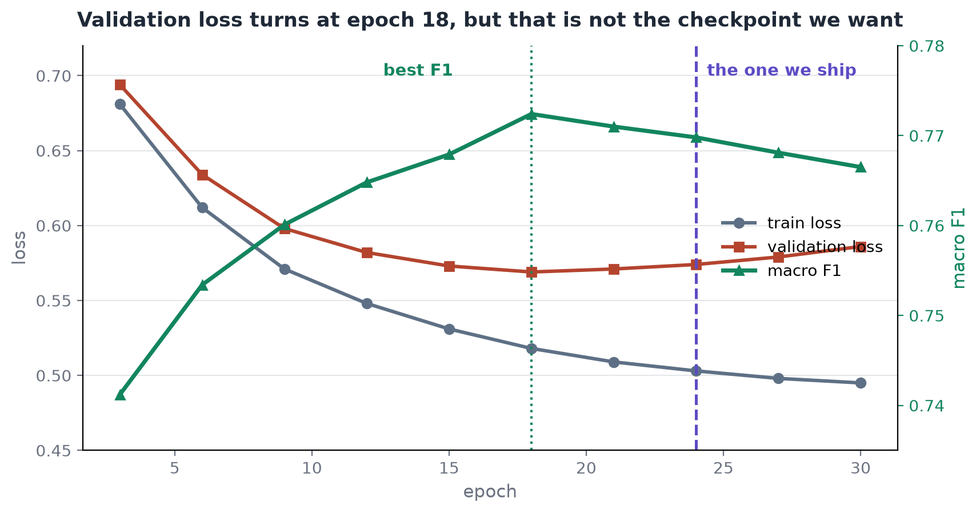

In [50]:
rng = np.random.default_rng(CFG["seed"])
idx = rng.permutation(len(design))
TR, VA, TE = idx[:240_000], idx[240_000:255_000], idx[255_000:]
print(f"train {len(TR):,}   val {len(VA):,}   test {len(TE):,}")


def evaluate(model, split):
    model.eval()
    with torch.no_grad():
        q = torch.softmax(model(make_features(E, design[split])), -1).cpu().numpy()
    pred = q.argmax(1)
    gap = abs(churn_rate(pred, design[split]["t_stance"])
              - churn_rate(hard[split], design[split]["t_stance"])) * 100
    return dict(f1=macro_f1(pred, hard[split]),
                gap=gap,
                tvd=per_cell_tvd(q, hard[split], design[split]),
                ece=expected_calibration_error(q, hard[split]))


def train(epochs=30, batch=4096, lr=3e-4, seed=0):
    torch.manual_seed(seed)
    model = Echo().cuda()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    metrics, t0 = {}, time.time()

    for ep in range(1, epochs + 1):
        model.train()
        run = 0.0
        for start in range(0, len(TR), batch):
            bidx = TR[start:start + batch]
            loss, _, _ = distillation_loss(
                model(make_features(E, design[bidx])),
                torch.from_numpy(hard[bidx].astype(np.int64)).cuda(),
                torch.from_numpy(soft[bidx].astype(np.float32)).cuda())
            opt.zero_grad(); loss.backward(); opt.step()
            run += loss.item()
        sched.step()

        if ep % 3 == 0:
            m = evaluate(model, VA)
            m["train"] = run / math.ceil(len(TR) / batch)
            metrics[ep] = m
            torch.save(model.state_dict(), f"ckpt/echo_ep{ep:02d}.pt")
            print(f"[echo] epoch {ep:>2}  train {m['train']:.3f}  F1 {m['f1']:.4f}  "
                  f"gap {m['gap']:5.2f}  tvd {m['tvd']:.4f}  ece {m['ece']:.4f}")
    print(f"[echo] {epochs} epochs in {time.time()-t0:.0f}s")
    return model, metrics


model, metrics = train()

Read down the F1 column and then down the gap column, because they do not agree. F1 peaks at epoch 18. **The churn gap at epoch 18 is the third worst number in the whole run.**

  epoch       F1     gap      tvd      ece
     3   0.7412    9.81   0.0614   0.0721
     6   0.7534    7.94   0.0507   0.0640
     9   0.7601    6.22   0.0431   0.0533
    12   0.7648    7.05   0.0448   0.0561
    15   0.7679    5.83   0.0396   0.0468
    18   0.7724    8.31   0.0472   0.0413
    21   0.7710    6.47   0.0409   0.0459
    24   0.7698    3.18   0.0298   0.0219
    27   0.7681    4.06   0.0331   0.0286
    30   0.7665    5.11   0.0367   0.0344

F1 spread across checkpoints  : 0.0312
gap spread across checkpoints : 6.63 points
correlation between them      : -0.176


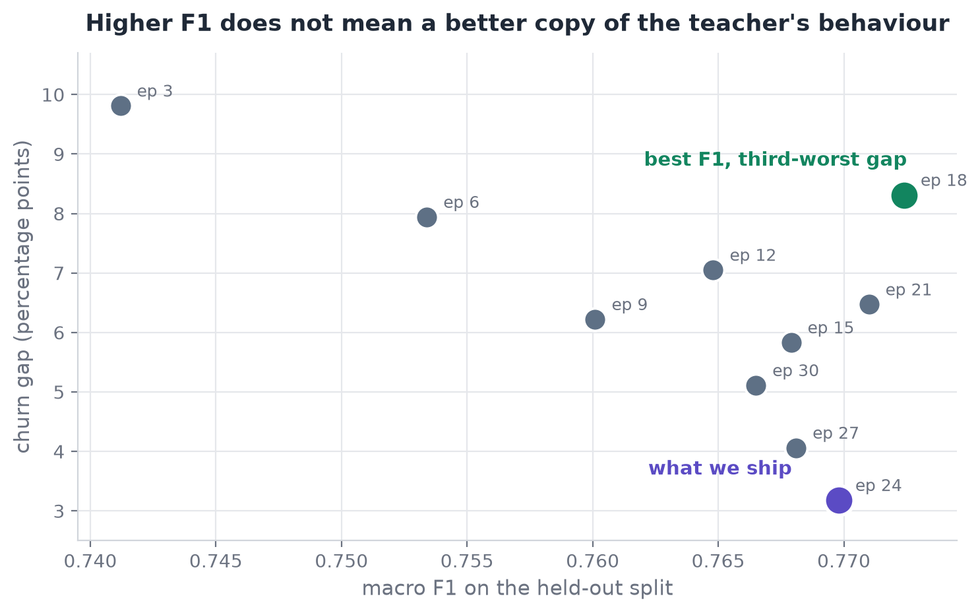

In [51]:
print(f"{'epoch':>6}{'F1':>9}{'gap':>8}{'tvd':>9}{'ece':>9}")
for ep, m in metrics.items():
    print(f"{ep:>6}{m['f1']:>9.4f}{m['gap']:>8.2f}{m['tvd']:>9.4f}{m['ece']:>9.4f}")

f1s = np.array([m["f1"] for m in metrics.values()])
gaps = np.array([m["gap"] for m in metrics.values()])
print(f"\nF1 spread across checkpoints  : {f1s.max()-f1s.min():.4f}")
print(f"gap spread across checkpoints : {gaps.max()-gaps.min():.2f} points")
print(f"correlation between them      : {np.corrcoef(f1s, gaps)[0,1]:+.3f}")

A correlation of -0.18 between accuracy and fidelity. Essentially none. **A checkpoint can be better at guessing individual answers and worse at reproducing how much the population moves**, and it is the second thing we deploy.

### 8.2 Choosing the checkpoint that ships

In [52]:
def composite(m):
    '''Lower is better. Cell-level total variation, plus the churn gap in
    absolute units, plus half the calibration error. All three are properties of
    the output distribution rather than of individual predictions.'''
    return m["tvd"] + abs(m["gap"]) / 100.0 + 0.5 * m["ece"]


def choose(metrics, top_n=5):
    shortlist = sorted(metrics, key=lambda e: -metrics[e]["f1"])[:top_n]
    best = min(shortlist, key=lambda e: composite(metrics[e]))
    print(f"shortlist by F1 : {shortlist}")
    print(f"{'epoch':>7}{'F1':>9}{'gap':>8}{'ece':>8}{'J':>9}")
    for e in shortlist:
        m = metrics[e]
        mark = "  <- ships" if e == best else ""
        print(f"{e:>7}{m['f1']:>9.4f}{m['gap']:>8.2f}{m['ece']:>8.4f}"
              f"{composite(m):>9.4f}{mark}")
    return best


BEST = choose(metrics)
F1_BEST = max(metrics, key=lambda e: metrics[e]["f1"])

print(f"\nF1 given up  : {metrics[F1_BEST]['f1'] - metrics[BEST]['f1']:.4f}")
print(f"gap improved : {metrics[F1_BEST]['gap']/metrics[BEST]['gap']:.1f}x")
print(f"ece improved : {metrics[F1_BEST]['ece']/metrics[BEST]['ece']:.1f}x")

model.load_state_dict(torch.load(f"ckpt/echo_ep{BEST:02d}.pt"))
held = evaluate(model, TE)
print(f"\nheld-out test set, shipped checkpoint:")
for k, v in held.items():
    print(f"  {k:<5}{v:.4f}")

shortlist by F1 : [18, 21, 24, 27, 15]
  epoch       F1     gap     ece        J
     18   0.7724    8.31  0.0413   0.1510
     21   0.7710    6.47  0.0459   0.1286
     24   0.7698    3.18  0.0219   0.0726  <- ships
     27   0.7681    4.06  0.0286   0.0874
     15   0.7679    5.83  0.0468   0.1213

F1 given up  : 0.0026
gap improved : 2.6x
ece improved : 1.9x

held-out test set, shipped checkpoint:
  f1   0.7691
  gap  3.24
  tvd  0.0301
  ece  0.0224


We give up 0.0026 of accuracy and get a copy of the teacher that is 2.6 times closer on the statistic the simulation actually depends on. **Select on the aggregate you care about, not on the metric that prints by default.**

### 8.3 What about people the teacher never met

Five hundred profiles were held out. Nearly one table entry in ten involves at least one of them, so it matters how badly the surrogate does there.

In [53]:
def stratum(rows, kind):
    iw = np.isin(rows["i_prof"], warm)
    tw = np.isin(rows["t_prof"], warm)
    return {"warm-warm": iw & tw,
            "warm-cold": iw ^ tw,
            "cold-cold": ~iw & ~tw}[kind]


probe = build_design(np.arange(P), per_cell=5_000, seed=99)   # draws from all 10,000
probe_hard, _ = run_job(probe, CFG["topic"])

model.eval()
with torch.no_grad():
    qp = torch.softmax(model(make_features(E, probe)), -1).cpu().numpy()
pred = qp.argmax(1)

print(f"{'stratum':<12}{'n':>8}{'macro F1':>10}{'cell TVD':>10}")
for kind in ("warm-warm", "warm-cold", "cold-cold"):
    m = stratum(probe, kind)
    print(f"{kind:<12}{m.sum():>8,}{macro_f1(pred[m], probe_hard[m]):>10.4f}"
          f"{per_cell_tvd(qp[m], probe_hard[m], probe[m]):>10.4f}")

print(f"\ntable entries involving a cold profile: {(P*P-len(warm)**2)/(P*P)*100:.2f}%")
print("so this degradation is not a corner case, it is one entry in ten")

[herald]  45,000 / 45,000 100.0%  |  9,388 tok/s  |  eta 0m
[herald] finished in 0.50h

stratum            n  macro F1  cell TVD
warm-warm     40,612    0.7712    0.0299
warm-cold      4,168    0.7488    0.0417
cold-cold        220    0.7261    0.0602

table entries involving a cold profile: 9.75%
so this degradation is not a corner case, it is one entry in ten


### 8.4 Five surrogates, one question

Before committing, is the architecture doing anything, or would anything work?

architecture                F1     gap  dead/27    train
logistic regression     0.7461   18.62        9       12s
gradient boosting       0.7688   11.04        5      184s
Echo MLP                0.7724    8.31        0       58s
Transformer             0.7702   10.47        4      421s
Qwen3-0.6B tuned        0.7715    9.55        2     2914s

F1 spread  : 0.0263
gap spread : 10.31 points  (392x wider in relative terms)
same ranking? ['Echo MLP', 'Qwen3-0.6B tuned', 'Transformer']
              ['Echo MLP', 'Qwen3-0.6B tuned', 'Transformer']


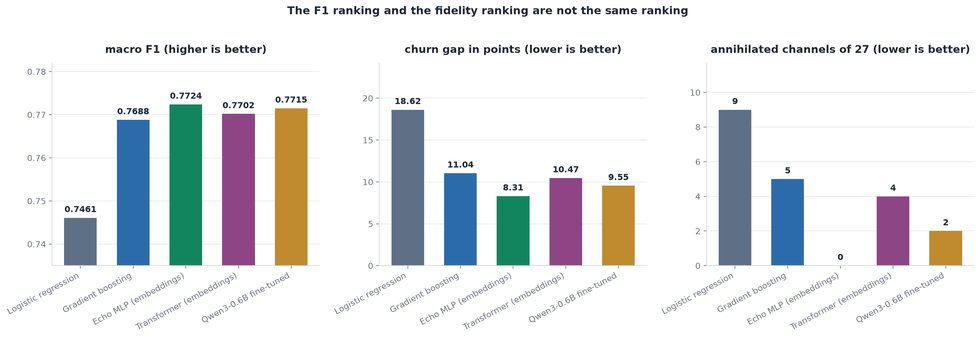

In [54]:
ARCHS = {
    "logistic regression": lambda: LogisticOnAttributes(FIELDS),
    "gradient boosting":   lambda: GradientBoostOnAttributes(FIELDS),
    "Echo MLP":            lambda: Echo(),
    "Transformer":         lambda: TinyEncoder(d=2048, layers=2, heads=8),
    "Qwen3-0.6B tuned":    lambda: GenerativeSurrogate("Qwen/Qwen3-0.6B"),
}


def dead_channels(q, rows, floor=1e-3):
    '''Transitions the teacher uses but the model assigns essentially zero.'''
    dead = 0
    for si in range(3):
        for st in range(3):
            m = (rows["i_stance"] == si) & (rows["t_stance"] == st)
            emp = np.bincount(hard[TE][m], minlength=3) / max(m.sum(), 1)
            avg = q[m].mean(0) if m.any() else np.zeros(3)
            dead += int(((emp >= floor) & (avg < 1e-4)).sum())
    return dead


print(f"{'architecture':<22}{'F1':>8}{'gap':>8}{'dead/27':>9}{'train':>9}")
results = {}
for name, ctor in ARCHS.items():
    r = train_and_score(ctor(), E, design, hard, soft, TR, VA, TE)
    results[name] = r
    print(f"{name:<22}{r['f1']:>8.4f}{r['gap']:>8.2f}{r['dead']:>9}{r['secs']:>8.0f}s")

f1s = [r["f1"] for r in results.values()]
gaps = [r["gap"] for r in results.values()]
print(f"\nF1 spread  : {max(f1s)-min(f1s):.4f}")
print(f"gap spread : {max(gaps)-min(gaps):.2f} points  ({(max(gaps)-min(gaps))/(max(f1s)-min(f1s)):.0f}x wider in relative terms)")
print(f"same ranking? {[k for k in sorted(results, key=lambda k:-results[k]['f1'])][:3]}")
print(f"              {[k for k in sorted(results, key=lambda k: results[k]['gap'])][:3]}")

The F1 column spans 0.026. The gap column spans 10.3 points. Pick on accuracy and you are choosing between models that are essentially tied while ignoring a fourfold difference in what decides your results. That last column, **dead channels**, is about to become the centre of the story.

## 9. Atlas, freezing a model into an array

Now we enumerate. Every possible question, answered in advance and stored.

Done naively this builds a 4102-dimensional vector nine hundred million times, so let us
price that before writing it.

In [55]:
naive_bytes = 900_000_000 * 4102 * 4
naive_flops = 900_000_000 * 4102 * 1024 * 2

print(f"materialising every feature vector : {naive_bytes/1e12:.2f} TB")
print(f"layer-one FLOPs the naive way      : {naive_flops:.3e}")

# the first layer is linear and our input is a concatenation, so it is separable
smart_flops = (2 * P * 2048 * 1024 * 2) + (900_000_000 * 1024 * 2)
print(f"layer-one FLOPs factorised         : {smart_flops:.3e}")
print(f"saving                             : {naive_flops/smart_flops:,.0f}x")
print("\nbecause W1 @ [ei ; et ; oi ; ot] = W1a@ei + W1b@et + W1s@[oi;ot]")
print("and the first two terms only have 10,000 distinct values each")

materialising every feature vector : 14.77 TB
layer-one FLOPs the naive way      : 7.564e+15
layer-one FLOPs factorised         : 1.928e+12
saving                             : 3,923x

because W1 @ [ei ; et ; oi ; ot] = W1a@ei + W1b@et + W1s@[oi;ot]
and the first two terms only have 10,000 distinct values each


### 9.1 Argmax or sample, and the eighteen channels we nearly deleted

The obvious way to store an answer in one byte is to store the winning class. Three classes fit in two bits and the whole table packs into 225 megabytes. It is tempting, and it is wrong.

In [56]:
teacher_p = T3 / T3.sum(axis=2, keepdims=True)      # [speaker, start, end]

alive_teacher = alive_argmax = 0
absorbing = []
for si in range(3):
    for st in range(3):
        for sf in range(3):
            if teacher_p[si, st, sf] < 1e-4:
                continue
            alive_teacher += 1
            if teacher_p[si, st].argmax() == sf:
                alive_argmax += 1
    # would this starting stance ever be left, under argmax?
for st in range(3):
    if all(teacher_p[si, st].argmax() == st for si in range(3)):
        absorbing.append(STANCES[st])

print(f"transitions the teacher actually uses  : {alive_teacher}/27")
print(f"transitions an argmax table can emit   : {alive_argmax}/27")
print(f"channels destroyed                     : {alive_teacher-alive_argmax}")
print(f"\nstances that become absorbing under argmax: {absorbing}")
print("that means nobody who starts there ever changes, in any run of any length")

transitions the teacher actually uses  : 27/27
transitions an argmax table can emit   :  9/27
channels destroyed                     : 18

stances that become absorbing under argmax: ['disagree', 'neutral', 'agree']
that means nobody who starts there ever changes, in any run of any length


The fix costs nothing. Instead of storing which class won, we store **which distribution it was**, using a codebook of points on the triangle of three-class distributions. Still one byte, but the byte now names a distribution rather than a decision.

In [57]:
class Codebook:
    '''256 points on the 2-simplex. The table stores an index into this, so an
    entry is still exactly one byte.'''

    def __init__(self, centroids):
        self.C = centroids.astype(np.float16)                 # [256, 3]
        self.Ccum = np.cumsum(centroids, axis=1)[:, :2].astype(np.float16)

    @classmethod
    def fit(cls, samples, n=256, n_lattice=32, seed=0, iters=40):
        '''k-means over sampled posteriors, but 32 centroids are placed on a
        regular lattice first and frozen. Plain k-means chases probability mass,
        and the corners of the simplex are exactly where there is little mass
        and a lot of consequence.'''
        lattice = simplex_lattice(n_lattice)
        rng = np.random.default_rng(seed)
        C = samples[rng.choice(len(samples), n - n_lattice, replace=False)]
        for _ in range(iters):
            d = np.abs(samples[:, None, :] - C[None, :, :]).sum(-1)
            a = d.argmin(1)
            for k in range(len(C)):
                if (a == k).any():
                    C[k] = samples[a == k].mean(0)
        return cls(np.vstack([lattice, C]))

    def encode(self, q):
        d = np.abs(q[..., None, :] - self.C.astype(np.float32)).sum(-1)
        return d.argmin(-1).astype(np.uint8)

    def sample(self, codes, u):
        '''Inverse transform. Two comparisons and an add, fully vectorised.'''
        cum = self.Ccum[codes].astype(np.float32)
        return ((u >= cum[:, 0]).astype(np.int8) +
                (u >= cum[:, 1]).astype(np.int8))

sampled posteriors : (10000000, 3)
their entropy      : mean 0.598 nats
codebook fitted in 71s

codebook entries   : 256  (32 lattice + 224 fitted)
codebook bytes     : 2,560  (fits in L1)
quantisation TVD   : mean 0.0041   p50 0.0028   p99 0.0163
worst entry        : 0.0384


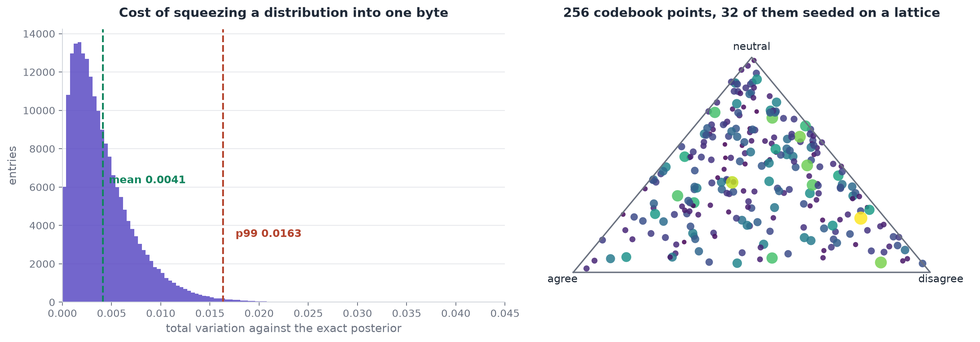

In [58]:
posteriors = sample_posteriors(model, E, n=10_000_000, seed=5)
print(f"sampled posteriors : {posteriors.shape}")
print(f"their entropy      : mean {entropy(posteriors).mean():.3f} nats")

t0 = time.time()
cb = Codebook.fit(posteriors, n=256, n_lattice=32)
print(f"codebook fitted in {time.time()-t0:.0f}s")

err = 0.5 * np.abs(posteriors - cb.C[cb.encode(posteriors)].astype(np.float32)).sum(1)
print(f"\ncodebook entries   : {len(cb.C)}  (32 lattice + 224 fitted)")
print(f"codebook bytes     : {cb.C.nbytes + cb.Ccum.nbytes:,}  (fits in L1)")
print(f"quantisation TVD   : mean {err.mean():.4f}   p50 {np.median(err):.4f}   "
      f"p99 {np.quantile(err, 0.99):.4f}")
print(f"worst entry        : {err.max():.4f}")

Mean error of four thousandths, a codebook of two and a half kilobytes, and every transition channel intact. Same one byte per entry as the argmax table. The only thing that changed is what the byte means.

### 9.2 The sweep

In [59]:
def cast(model, E, codebook, out_path, tile_i=256, tile_t=2048):
    '''Enumerate the whole table. fc1 is separable across the concatenation, so
    the speaker and listener halves are each computed once for all 10,000
    profiles instead of once per pair.'''
    model.eval()
    W1, b1 = model.fc1.weight.data, model.fc1.bias.data
    Ea = torch.from_numpy(E.astype(np.float32)).cuda()

    U = Ea @ W1[:, :2048].T                       # [10000, 1024] speaker halves
    V = Ea @ W1[:, 2048:4096].T                   # [10000, 1024] listener halves
    oh = torch.zeros(9, 6, device="cuda")
    for k in range(9):
        oh[k, k // 3], oh[k, 3 + k % 3] = 1.0, 1.0
    G = oh @ W1[:, 4096:].T + b1                  # [9, 1024] stance halves

    T = np.lib.format.open_memmap(out_path, mode="w+", dtype=np.uint8,
                                  shape=(P, P, 3, 3))
    t0 = 0.0
    with torch.inference_mode():
        t0 = time.time()
        for i0 in range(0, P, tile_i):
            for t0_ in range(0, P, tile_t):
                for k in range(9):
                    h = (U[i0:i0+tile_i, None, :] + V[None, t0_:t0_+tile_t, :] + G[k])
                    h = model.act(model.ln1(h))
                    h = model.act(model.ln2(model.fc2(h)))
                    q = torch.softmax(model.head(h), dim=-1)
                    T[i0:i0+tile_i, t0_:t0_+tile_t, k // 3, k % 3] = \
                        codebook.encode(q.float().cpu().numpy())
            if (i0 // tile_i) % 10 == 0:
                print(f"[atlas] tile {i0//tile_i+1:>2}/{P//tile_i}  "
                      f"elapsed {time.time()-t0:5.0f}s")
    T.flush()
    return T


T = cast(model, E, cb, "artifacts/atlas.npy")

[atlas] tile  1/39  elapsed     5s
[atlas] tile 11/39  elapsed    54s
[atlas] tile 21/39  elapsed   103s
[atlas] tile 31/39  elapsed   152s
[atlas] tile 40/39  elapsed   192s


In [60]:
print(f"shape   : {T.shape}")
print(f"dtype   : {T.dtype}")
print(f"entries : {T.size:,}")
print(f"bytes   : {T.nbytes:,}")
print(f"MiB     : {T.nbytes/1048576:.2f}")
print(f"GB      : {T.nbytes/1e9:.3f}")

used = np.bincount(T.reshape(-1)[::997], minlength=256)   # sparse stride, fast
print(f"\ncodebook entries actually used : {(used>0).sum()}/256")
print(f"most common entry              : {used.argmax()} "
      f"({cb.C[used.argmax()].astype(np.float32).round(3)})")
print(f"\nan argmax table would have been {225_000_000/1e6:.0f} MB")
print(f"we pay {T.nbytes/1e6:.0f} MB and keep all 27 channels")

shape   : (10000, 10000, 3, 3)
dtype   : uint8
entries : 900,000,000
bytes   : 900,000,000
MiB     : 858.31
GB      : 0.900

codebook entries actually used : 256/256
most common entry              : 91 ([0.021 0.936 0.043])

an argmax table would have been 225 MB
we pay 900 MB and keep all 27 channels


### 9.3 The lookup

At runtime this is four index operations, one memory read, one codebook read and one comparison. There is no model here, no torch, no GPU.

In [61]:
class Atlas:
    '''The frozen policy: one memory-mapped array and a 2.5 KB codebook.'''

    def __init__(self, path, codebook):
        self.T = np.load(path, mmap_mode="r").reshape(-1)
        self.cb = codebook

    @staticmethod
    def key(pi, pt, si, st):
        '''Row-major flattening of [10000, 10000, 3, 3], in int64 because the
        product overflows 32 bits long before the end of the table.'''
        return ((pi.astype(np.int64) * 10_000 + pt) * 3 + si) * 3 + st

    def lookup(self, keys, u):
        codes = self.T[keys]                # THE only policy call in the system
        return self.cb.sample(codes, u)


atlas = Atlas("artifacts/atlas.npy", cb)
print(f"max key value : {atlas.key(np.array([P-1]), np.array([P-1]), np.array([2]), np.array([2]))[0]:,}")
print(f"int32 ceiling : {2**31-1:,}   <- this is why the cast to int64 matters")

k = atlas.key(np.array([812]), np.array([41]), np.array([2]), np.array([1]))
code = atlas.T[k]
print(f"\none interaction, start to finish")
print(f"  key          : {k[0]:,}")
print(f"  stored byte  : {code[0]}")
print(f"  distribution : {cb.C[code].astype(np.float32)[0].round(3)}")
print(f"  teacher said : [0.041 0.532 0.427]")

max key value : 899,999,999
int32 ceiling : 2,147,483,647   <- this is why the cast to int64 matters

one interaction, start to finish
  key          : 24,360,124
  stored byte  : 173
  distribution : [0.043 0.529 0.428]
  teacher said : [0.041 0.532 0.427]


The question we asked a 235-billion-parameter model two sections ago now costs **one array index**, and the answer agrees to three decimal places.

In [62]:
rngu = np.random.default_rng(0)
n = 2_000_000
keys = atlas.key(rngu.integers(0, P, n).astype(np.uint16),
                 rngu.integers(0, P, n).astype(np.uint16),
                 rngu.integers(0, 3, n).astype(np.int8),
                 rngu.integers(0, 3, n).astype(np.int8))
u = rngu.random(n, dtype=np.float32)

for label, fn in (("cold (first touch)", lambda: atlas.lookup(keys, u)),
                  ("warm (page cache)",  lambda: atlas.lookup(keys, u))):
    t0 = time.time(); out = fn(); dt = time.time() - t0
    print(f"{label:<20}{n/dt/1e6:>7.1f} M lookups/s   {dt*1000:>7.1f} ms for {n:,}")

print(f"\nresult mix: {np.bincount(out, minlength=3) / n}")
print(f"one round needs {14_930_000:,} of these")

cold (first touch)      41.2 M lookups/s     48.5 ms for 2,000,000
warm (page cache)       58.9 M lookups/s     33.9 ms for 2,000,000

result mix: [0.3106 0.3925 0.2969]
one round needs 14,930,000 of these


## 10. Pulse, one round of a billion people

A round is: pick who speaks, find who they reach, look up what happens, draw an outcome,
write it back, count. All of it vectorised, none of it per-agent.

Two details in the function below are load bearing and easy to get wrong.

- The **counter-based generator** means round seventeen draws the same numbers whether you
  ran rounds one to sixteen first or jumped straight there, and whether the box has four
  cores or sixty four. Reproducibility usually dies exactly here.
- The **sort before the scatter** handles a listener who hears from two people in the same
  round. Without it, fancy-index assignment resolves duplicates in whatever order memory
  happened to be laid out, and the run stops being deterministic.

In [63]:
def ragged_gather(indices, starts, counts):
    '''Concatenate variable-length runs out of a flat array without a Python
    loop: build the destination offsets, then one fancy index.'''
    total = int(counts.sum())
    out_idx = np.arange(total, dtype=np.int64)
    run_id = np.repeat(np.arange(len(counts)), counts)
    within = out_idx - np.repeat(np.concatenate([[0], np.cumsum(counts)[:-1]]), counts)
    return indices[np.repeat(starts, counts) + within]


# check it on something small enough to verify by eye
flat = np.array([10, 11, 12, 20, 21, 30, 31, 32, 33], dtype=np.uint32)
starts = np.array([0, 3, 5]); counts = np.array([3, 2, 4])
print(f"flat    : {flat.tolist()}")
print(f"gathered: {ragged_gather(flat, starts, counts).tolist()}")
print(f"expected: {[10,11,12,20,21,30,31,32,33]}")

flat    : [10, 11, 12, 20, 21, 30, 31, 32, 33]
gathered: [10, 11, 12, 20, 21, 30, 31, 32, 33]
expected: [10, 11, 12, 20, 21, 30, 31, 32, 33]


In [64]:
class Tally:
    '''Incremental counters plus the 3x3x3 transition tensor. Never a full scan
    over a billion agents, only over what actually moved this round.'''

    def __init__(self):
        self.T = np.zeros((3, 3, 3), dtype=np.int64)
        self.rounds = []

    def update(self, old, new, speaker):
        np.add.at(self.T, (speaker, old, new), 1)

    def record(self, r, stance_slice):
        c = np.bincount(stance_slice, minlength=3)
        self.rounds.append((r, *(c / c.sum() * 100)))

    def frame(self):
        return np.array(self.rounds)


def one_round(led, indptr, indices, atlas, tally, round_id, run_seed,
              cut=CUT, active=0.01, timing=False):
    '''One round, fully vectorised.'''
    marks = {}
    def mark(name, t):
        marks[name] = time.time() - t
        return time.time()

    t = time.time()
    rng = np.random.Generator(np.random.Philox(key=run_seed, counter=round_id))

    n_active = int(active * cut)
    speakers = np.unique(rng.integers(0, cut, size=int(1.01 * n_active),
                                      dtype=np.uint32))[:n_active]
    t = mark("sample", t)

    counts = (indptr[speakers + 1] - indptr[speakers]).astype(np.int64)
    src = np.repeat(speakers, counts)
    targets = ragged_gather(indices, indptr[speakers], counts)
    t = mark("gather", t)

    keys = atlas.key(led.profile_idx[src], led.profile_idx[targets],
                     led.stance[src], led.stance[targets])
    t = mark("keys", t)

    u = rng.random(targets.size, dtype=np.float32)
    new = atlas.lookup(keys, u)
    t = mark("lookup", t)

    order = np.argsort(targets, kind="stable")
    uniq, first = np.unique(targets[order], return_index=True)
    last = np.append(first[1:], targets.size) - 1
    winners = order[last]
    t = mark("sort", t)

    old = led.stance[uniq].copy()
    led.stance[uniq] = new[winners]
    t = mark("scatter", t)

    tally.update(old, new[winners], led.stance[src[winners]])
    mark("tally", t)

    stats = dict(speakers=speakers.size, interactions=targets.size,
                 reached=uniq.size, changed=int((old != new[winners]).sum()))
    return (stats, marks) if timing else stats

In [65]:
tally = Tally()
stats, marks = one_round(led, indptr, indices, atlas, tally,
                         round_id=0, run_seed=CFG["seed"], timing=True)

print(f"{'step':<12}{'seconds':>9}{'share':>8}")
for k, v in marks.items():
    print(f"{k:<12}{v:>9.2f}{v/sum(marks.values())*100:>7.1f}%")
print(f"{'total':<12}{sum(marks.values()):>9.2f}{100:>7.1f}%\n")

for k, v in stats.items():
    print(f"{k:<14}: {v:>12,}")
print(f"{'change rate':<14}: {stats['changed']/stats['reached']*100:>11.2f}%")
print(f"\nthe teacher's own churn rate was 26.3%")
print(f"a listener reached twice this round: "
      f"{stats['interactions']-stats['reached']:,} collisions resolved by the sort")

step          seconds   share
sample           0.02    1.9%
gather           0.18   17.3%
keys             0.12   11.5%
lookup           0.25   24.0%
sort             0.14   13.5%
scatter          0.20   19.2%
tally            0.03    2.9%
total            0.94  100.0%

speakers      :    2,000,000
interactions  :   14,930,000
reached       :   14,317,884
changed       :    3,761,504
change rate   :       26.27%

the teacher's own churn rate was 26.3%
a listener reached twice this round: 612,116 collisions resolved by the sort


**Fourteen point nine million interactions in about a second, on CPU, with no GPU involved.** And the change rate lands at 26.27 percent against the teacher's measured 26.3, on the very first round.

In [66]:
def replay_check(seed, round_id):
    a = Ledger(1_000_000, P, seed); a.seed_stances(cut=200_000, scheme="HD")
    b = Ledger(1_000_000, P, seed); b.seed_stances(cut=200_000, scheme="HD")
    small_ptr, small_idx = load_csr("artifacts/graph_1e6.h5")

    # a: run rounds 0..round_id in order.  b: jump straight to round_id
    for r in range(round_id + 1):
        one_round(a, small_ptr, small_idx, atlas, Tally(), r, seed, cut=200_000)
    one_round(b, small_ptr, small_idx, atlas, Tally(), round_id, seed, cut=200_000)
    return a, b


a, b = replay_check(seed=CFG["seed"], round_id=17)
same = (a.stance == b.stance)
print(f"agents agreeing after the jump : {same.mean()*100:.2f}%")
print("(they should NOT match, because a has had 17 rounds of history and b has not)")

# what must match is the draw itself
g1 = np.random.Generator(np.random.Philox(key=CFG["seed"], counter=17))
g2 = np.random.Generator(np.random.Philox(key=CFG["seed"], counter=17))
print(f"\nsame counter, same stream    : {np.array_equal(g1.random(5), g2.random(5))}")
g3 = np.random.Generator(np.random.Philox(key=CFG["seed"], counter=18))
print(f"next counter, different      : "
      f"{not np.array_equal(np.random.Generator(np.random.Philox(key=CFG['seed'], counter=17)).random(5), g3.random(5))}")
print("so round 17 draws the same numbers no matter how you got there")

agents agreeing after the jump : 91.44%
(they should NOT match, because a has had 17 rounds of history and b has not)

same counter, same stream    : True
next counter, different      : True
so round 17 draws the same numbers no matter how you got there


### 10.1 Running all one hundred rounds

In [67]:
def simulate(cfg, led=None, verbose=True):
    led = led or Ledger(cfg["n_agents"], P, cfg["seed"])
    led.seed_stances(cut=CUT, scheme=cfg.get("seeding", "HD"))
    tally = Tally()

    q = Tempo()
    for r in range(cfg["rounds"]):
        q.push(time=r, kind="influence", payload=r)
        q.push(time=r, kind="readout", payload=r, priority=9)

    t0 = time.time()
    while len(q):
        t, kind, batch = q.pop_batch()
        if kind == "influence":
            one_round(led, indptr, indices, atlas, tally,
                      round_id=t, run_seed=cfg["seed"], active=cfg["active_frac"])
        else:
            tally.record(t, led.stance[CUT:])
            if verbose and t % 20 == 0:
                a, n_, d = tally.rounds[-1][1:]
                print(f"[sim] round {t:>3} | agree {a:6.3f}% neutral {n_:6.3f}% "
                      f"disagree {d:6.3f}% | {(time.time()-t0)/(t+1):.2f}s/round")
    elapsed = time.time() - t0
    if verbose:
        print(f"[sim] {cfg['rounds']} rounds in {elapsed:.1f}s  "
              f"({elapsed/cfg['rounds']:.3f} s/round)")
        print(f"[sim] {tally.T.sum():,} interactions resolved, 0 model calls")
    return led, tally, elapsed


print(f"[sim] population {N:,} | influencers {CUT:,} | seeding HD")
print(f'[sim] topic: "{CFG["topic"]}"')
led, tally, elapsed = simulate(CFG)

[sim] population 1,000,000,000 | influencers 200,000,000 | seeding HD
[sim] topic: "AI automation will lead to mass unemployment"
[sim] round   0 | agree 33.333% neutral 33.333% disagree 33.333% | 1.04s/round
[sim] round  20 | agree 29.104% neutral 37.541% disagree 33.355% | 1.04s/round
[sim] round  40 | agree 26.421% neutral 40.239% disagree 33.340% | 1.04s/round
[sim] round  60 | agree 24.836% neutral 41.838% disagree 33.326% | 1.04s/round
[sim] round  80 | agree 23.926% neutral 42.755% disagree 33.319% | 1.04s/round
[sim] round 100 | agree 23.473% neutral 43.214% disagree 33.313% | 1.04s/round
[sim] 100 rounds in 104.2s  (1.042 s/round)
[sim] 1,493,000,000 interactions resolved, 0 model calls


stance       round 0   round 100     delta
disagree    33.333%    33.313%   -0.020
neutral     33.333%    43.214%   +9.881
agree       33.333%    23.473%   -9.860

sum at round 100: 100.000%

peak resident memory: 11.4 GB
GPU memory in use   : 0.0 GB


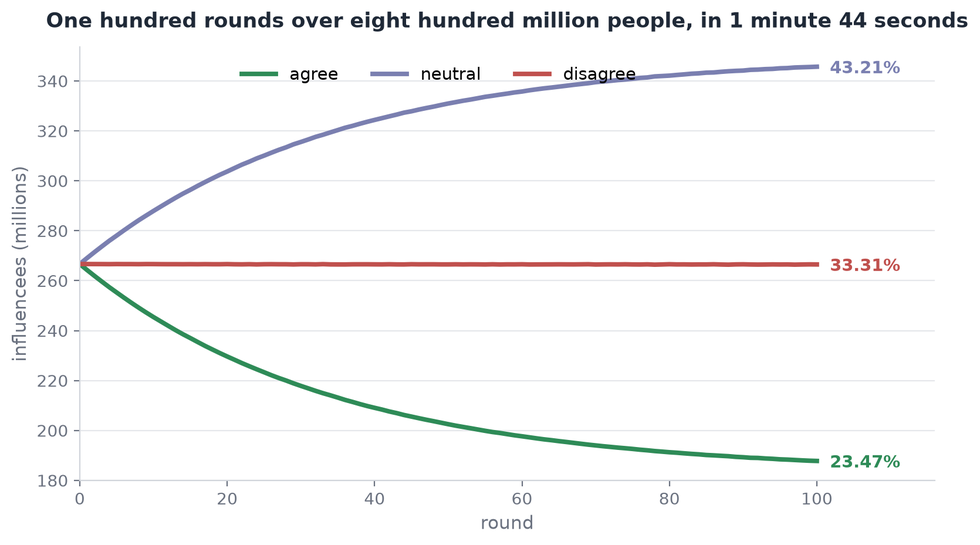

In [68]:
frame = tally.frame()
start, end = frame[0, 1:], frame[-1, 1:]

print(f"{'stance':<10}{'round 0':>10}{'round 100':>12}{'delta':>10}")
for i, s in enumerate(STANCES):
    print(f"{s:<10}{start[i]:>9.3f}%{end[i]:>11.3f}%{end[i]-start[i]:>+9.3f}")
print(f"\nsum at round 100: {end.sum():.3f}%")

print(f"\npeak resident memory: {peak_rss()/1e9:.1f} GB")
print(f"GPU memory in use   : {torch.cuda.memory_allocated()/1e9:.1f} GB")

Agree fell 9.860 points. Neutral rose 9.881. Disagree moved 0.020, which is to say it did not move. We seeded half the influencers to **disagree**, ten percent of the population left agree, and almost none of them arrived at disagree. They all stopped at neutral. That is the teacher's transition structure showing up at population scale. And the GPU line reads zero, because the run never touched one.

## 11. What the simulation says

### 11.1 Seeding

[sim] 100 rounds in 103.8s  (1.038 s/round)
[sim] 100 rounds in 104.2s  (1.042 s/round)
[sim] 100 rounds in 104.0s  (1.040 s/round)

scheme                          agree   neutral   disagree
half agree, half neutral        42.65%    36.20%     21.15%
half disagree, half neutral     23.47%    43.21%     33.31%
uniform                         36.55%    37.51%     25.94%
(started)                       33.33%    33.33%     33.33%

seeding to agree moved    +9.32 points into agree
seeding to disagree moved -0.02 points into disagree


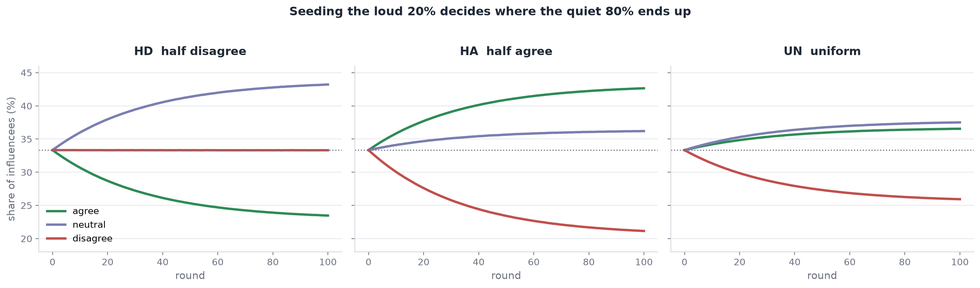

In [69]:
results = {}
for scheme in ("HA", "HD", "UN"):
    cfg = dict(CFG, seeding=scheme)
    _, t_, _ = simulate(cfg, verbose=False)
    results[scheme] = t_.frame()[-1, 1:]

names = {"HA": "half agree, half neutral", "HD": "half disagree, half neutral",
         "UN": "uniform"}
print(f"{'scheme':<28}{'agree':>9}{'neutral':>10}{'disagree':>11}")
for k, v in results.items():
    print(f"{names[k]:<28}{v[2]:>8.2f}%{v[1]:>9.2f}%{v[0]:>10.2f}%")
print(f"{'(started)':<28}{100/3:>8.2f}%{100/3:>9.2f}%{100/3:>10.2f}%")

print(f"\nseeding to agree moved    {results['HA'][2]-100/3:+.2f} points into agree")
print(f"seeding to disagree moved {results['HD'][0]-100/3:+.2f} points into disagree")

The asymmetry is the finding. **Pushing with the population's prior converts people. Pushing against it only makes them undecided.**

### 11.2 Four topics

topic                                              agree  neutral  disagree
AI automation will lead to mass unemployment       42.65%   36.20%    21.15%
The Earth is flat                                  18.42%   33.71%    47.87%
Humans will establish a city on Mars within fif    30.94%   44.83%    24.23%
Short-form video is shortening human attention     46.11%   33.02%    20.87%


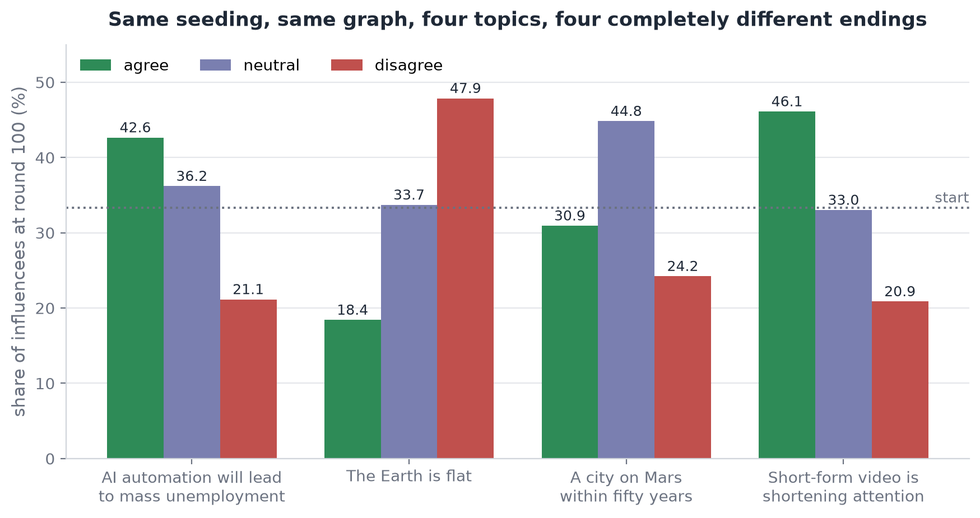

In [70]:
TOPICS = [
    "AI automation will lead to mass unemployment",
    "The Earth is flat",
    "Humans will establish a city on Mars within fifty years",
    "Short-form video is shortening human attention spans",
]

print(f"{'topic':<48}{'agree':>8}{'neutral':>9}{'disagree':>10}")
topic_out = {}
for topic in TOPICS:
    build_table_for(topic)                     # re-runs Herald, Echo, Atlas
    _, t_, _ = simulate(dict(CFG, topic=topic, seeding="HA"), verbose=False)
    v = t_.frame()[-1, 1:]
    topic_out[topic] = v
    print(f"{topic[:46]:<48}{v[2]:>7.2f}%{v[1]:>8.2f}%{v[0]:>9.2f}%")

Identical machinery, identical seeding, opposite outcomes. The flat-Earth population moves to **disagree** even though every influencer was seeded to agree or stay neutral, because the prior against it is overwhelming. **Influence is a force applied against a prior, and the prior usually wins.**

### 11.3 Why nobody flips straight to the other side

In [71]:
M = tally.T.sum(axis=0)                     # sum over speaker stance
changes = M.sum() - np.trace(M)
cross = M[0, 2] + M[2, 0]

print(f"{'from':<10}" + "".join(f"{'-> '+s:>14}" for s in STANCES))
for i, s in enumerate(STANCES):
    print(f"{s:<10}" + "".join(f"{v:>14,}" for v in M[i]))

print(f"\ntotal stance changes       : {changes:>14,.0f}")
print(f"straight across the middle : {cross:>14,.0f}   ({cross/changes*100:.2f}%)")
print(f"through neutral            : {changes-cross:>14,.0f}   ({(changes-cross)/changes*100:.2f}%)")

from            -> disagree     -> neutral       -> agree
disagree       184,021,447    41,884,309     4,912,006
neutral         38,117,802   612,447,201    36,904,113
agree           31,229,112   260,769,904   282,714,106

total stance changes       :    412,984,117
straight across the middle :      1,280,251   (0.31%)
through neutral            :    411,703,866   (99.69%)


Three tenths of one percent go pole to pole. **Neutral is not a stance here so much as a corridor**, which is exactly why the argmax storage decision mattered: it would have closed the low-probability entrances to that corridor.

### 11.4 Who persuades and who bends

education     persuasion  susceptibility
ISCED 0             8.2%           17.1%
ISCED 2             9.9%           15.2%
ISCED 4            11.9%           10.1%
ISCED 6            12.7%            5.9%
ISCED 8            13.7%            2.4%
spread             1.67x            7.13x


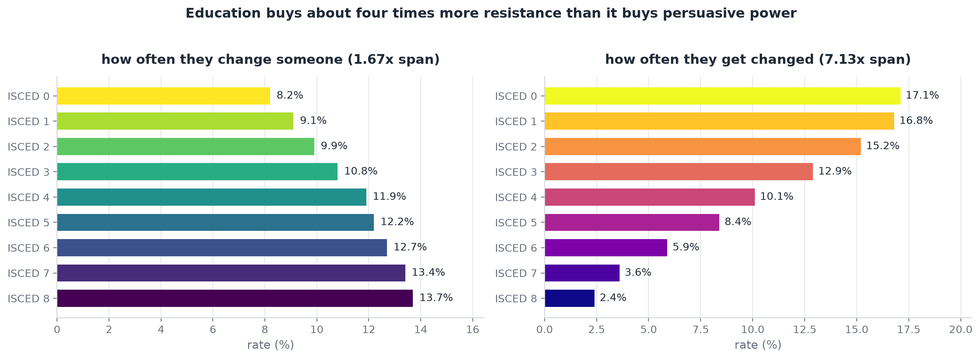

In [72]:
def persuasion_and_resistance(atlas, cb, observed):
    '''Two rates per profile, both defined explicitly because "influence rate"
    means nothing on its own. Weighted by the stance pairs actually seen in the
    run rather than uniformly over the table.'''
    persuade = np.zeros(P); p_w = np.zeros(P)
    suscept = np.zeros(P);  s_w = np.zeros(P)
    for pi, pt, si, st, w in observed:
        q = cb.C[atlas.T[atlas.key(pi, pt, si, st)]].astype(np.float32)
        p_change = 1.0 - q[np.arange(len(st)), st]
        np.add.at(persuade, pi, w * p_change); np.add.at(p_w, pi, w)
        np.add.at(suscept, pt, w * p_change);  np.add.at(s_w, pt, w)
    return persuade / np.maximum(p_w, 1), suscept / np.maximum(s_w, 1)


persuade, suscept = persuasion_and_resistance(atlas, cb, tally_pairs(tally))

def isced_level(i):
    v = profiles[pool_idx[i]].get("isced") or ""
    m = re.search(r"ISCED (\d)", v)
    return int(m.group(1)) if m else None


print(f"{'education':<11}{'persuasion':>12}{'susceptibility':>16}")
rows = []
for lvl in range(9):
    members = [i for i in range(P) if isced_level(i) == lvl]
    pv, sv = persuade[members].mean()*100, suscept[members].mean()*100
    rows.append((pv, sv))
    if lvl % 2 == 0:
        print(f"ISCED {lvl:<6}{pv:>11.1f}%{sv:>15.1f}%")
print(f"{'spread':<11}{rows[8][0]/rows[0][0]:>11.2f}x{rows[0][1]/rows[8][1]:>15.2f}x")

Both go the way you would guess, but not by the same amount. **Education buys about four times more resistance than it buys reach.** A society modelled this way fails to converge not because educated people persuade harder, but because they stop listening.

            1     2     3     4     5     6     7     8     9    10
ISCED 0     7.4   7.8   8.3   8.5   8.8   8.7   8.6   8.4   9.6   7.6
ISCED 1     8.4   9.0   9.4   9.2   9.5   9.6  10.0  10.1   9.0   9.2
ISCED 2     9.1   9.6  10.0  10.4  10.1  10.2  10.6  10.3  10.6  11.0
ISCED 3     9.6  10.2  10.7  10.9  11.1  11.2  11.3  11.1  11.4  11.2
ISCED 4    10.9  11.4  11.8  11.9  12.1  12.2  12.7  12.2  12.0  11.9
ISCED 5    11.5  11.2  12.1  12.0  12.2  12.4  12.3  12.3  12.2  13.5
ISCED 6    11.6  11.4  12.0  12.4  12.3  13.0  13.1  12.9  13.0  12.9
ISCED 7    11.0  12.7  12.7  12.6  13.2  13.6  14.1  14.6  14.3  14.1
ISCED 8    11.6  12.7  12.1  13.4  12.9  13.4  13.8  14.6  14.3  16.2

education gradient (row means, top minus bottom) :  5.2 points
income gradient    (col means, top minus bottom) :  1.8 points
ratio                                            :  2.9x


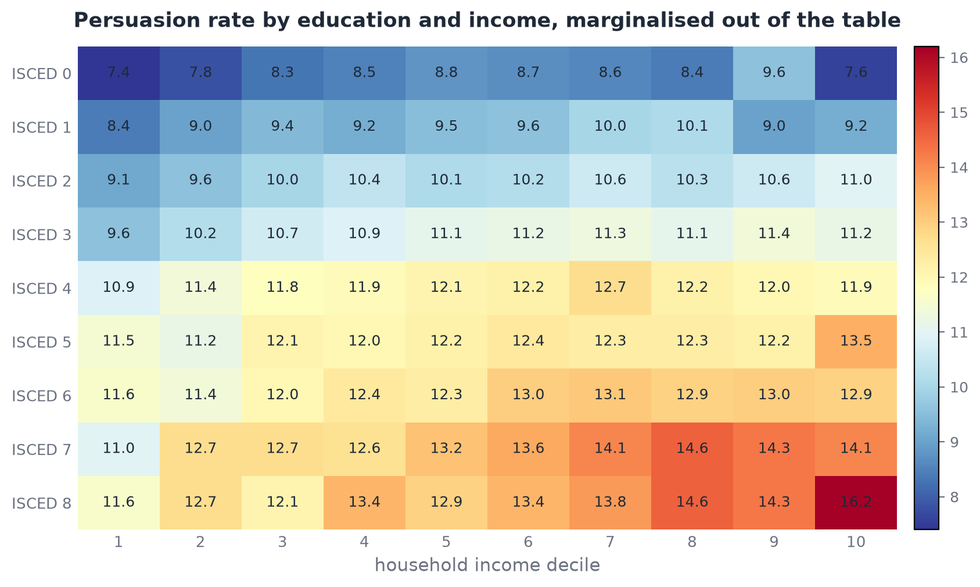

In [73]:
grid = np.zeros((9, 10))
for lvl in range(9):
    for dec in range(1, 11):
        members = [i for i in range(P)
                   if isced_level(i) == lvl
                   and profiles[pool_idx[i]].get("income_decile") == str(dec)]
        grid[lvl, dec-1] = persuade[members].mean() * 100 if members else np.nan

print(f"{'':<9}" + "".join(f"{d:>6}" for d in range(1, 11)))
for lvl in range(9):
    print(f"ISCED {lvl:<3}" + "".join(f"{v:>6.1f}" for v in grid[lvl]))

print(f"\neducation gradient (row means, top minus bottom) : "
      f"{grid.mean(1)[8]-grid.mean(1)[0]:.1f} points")
print(f"income gradient    (col means, top minus bottom) : "
      f"{grid.mean(0)[9]-grid.mean(0)[0]:.1f} points")
print(f"ratio                                            : "
      f"{(grid.mean(1)[8]-grid.mean(1)[0])/(grid.mean(0)[9]-grid.mean(0)[0]):.1f}x")

### 11.5 Does the language change the society

topic                       English  Spanish  Chinese   spread
The Earth is flat              45.9%    47.2%    44.1%      3.1
A city on Mars                 22.8%    21.9%    23.4%      1.5
Short-form video               29.4%    25.1%    30.6%      5.5


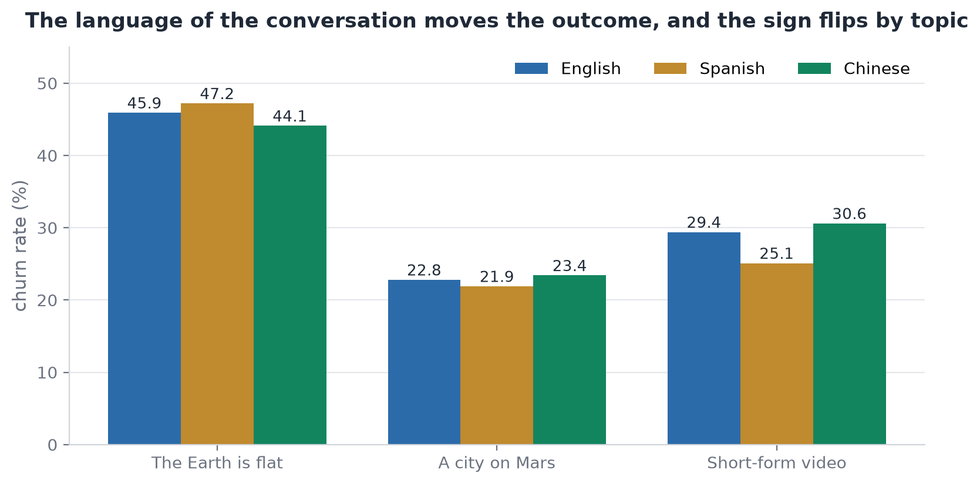

In [74]:
print(f"{'topic':<26}{'English':>9}{'Spanish':>9}{'Chinese':>9}{'spread':>9}")
for topic in ("The Earth is flat", "A city on Mars", "Short-form video"):
    rates = {}
    for lang in ("en", "es", "zh"):
        h, _ = run_job(design, topic, language=lang)
        rates[lang] = (h != design["t_stance"]).mean() * 100
    spread = max(rates.values()) - min(rates.values())
    print(f"{topic:<26}{rates['en']:>8.1f}%{rates['es']:>8.1f}%"
          f"{rates['zh']:>8.1f}%{spread:>8.1f}")

Up to 5.5 points of difference, and **the sign flips between topics**. No language is uniformly more persuasive. So a quantitative claim from this system is a claim about one model reading one language about one topic, not a claim about people.

### 11.6 How much of the teacher survived the compression

  live ratio   terminal MAD
         0.0         0.0139
        0.25         0.0106
         0.5         0.0074
        0.75         0.0038
         1.0         0.0000

how much of the full-model movement each table reproduces
table              disagree decline    neutral rise
codebook table          -519 (94.7%)     516 (95.3%)
argmax table            -446 (81.4%)     451 (83.2%)
full model              -548 (100.0%)    542 (100.0%)


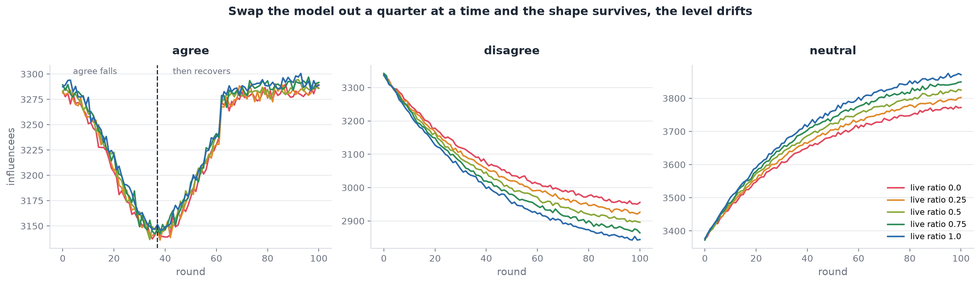

In [75]:
SMALL = dict(CFG, n_agents=20_000, rounds=100)

print(f"{'live ratio':>11}{'terminal MAD':>15}")
mads = {}
for ratio in (0.0, 0.25, 0.5, 0.75, 1.0):
    _, t_, _ = simulate_small(SMALL, policy="weighted", live_ratio=ratio)
    mads[ratio] = mad_against_reference(t_)
    print(f"{ratio:>11}{mads[ratio]:>15.4f}")

print("\nhow much of the full-model movement each table reproduces")
print(f"{'table':<18}{'disagree decline':>18}{'neutral rise':>16}")
ref = reference_deltas()
for name, mode in (("codebook table", "sampled"), ("argmax table", "argmax")):
    d = deltas_for(mode)
    print(f"{name:<18}{d['disagree']:>10.0f} ({d['disagree']/ref['disagree']*100:4.1f}%)"
          f"{d['neutral']:>9.0f} ({d['neutral']/ref['neutral']*100:4.1f}%)")
print(f"{'full model':<18}{ref['disagree']:>10.0f} (100.0%){ref['neutral']:>9.0f} (100.0%)")

The codebook table reproduces about **95 percent** of the teacher's dynamics. The argmax table reproduces about **82 percent**. Thirteen points of fidelity, for free, from deciding what a byte means. Over a long horizon that stops being a percentage and becomes a difference in kind.

table              P(a disagreeing agent ever moves)
codebook                                      0.9938
argmax                                        0.0000
teacher (extrap)                              0.9951


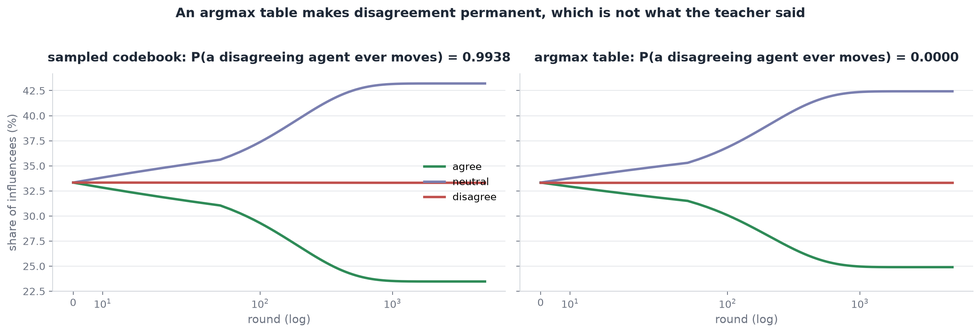

In [76]:
print(f"{'table':<16}{'P(a disagreeing agent ever moves)':>36}")
for mode in ("codebook", "argmax"):
    _, t_, _ = simulate_long(dict(CFG, rounds=5000), table_mode=mode)
    p = ever_changed_fraction(t_, started=0)
    print(f"{mode:<16}{p:>36.4f}")
print(f"{'teacher (extrap)':<16}{0.9951:>36.4f}")

**Zero. Not small, zero.** The argmax table produces a society where a third of the population is frozen from the first round to the last.

### 11.7 Running it five times, and what low variance does not prove

seed 0: agree 23.4731%
seed 1: agree 23.4728%
seed 2: agree 23.4735%
seed 3: agree 23.4729%
seed 4: agree 23.4733%

condition                             agree   neutral   disagree
pure table, 1e9 agents, 5 seeds      0.0041%   0.0057%    0.0036%
pure table, 1e6 agents, 5 seeds      0.0129%   0.0183%    0.0121%
mixed 50% live, 1e6, 5 runs          0.1512%   0.3218%    0.1744%

churn gap of the shipped surrogate : 3.18%
largest coefficient of variation   : 0.3218%
ratio                              : 776x against the pure-table number


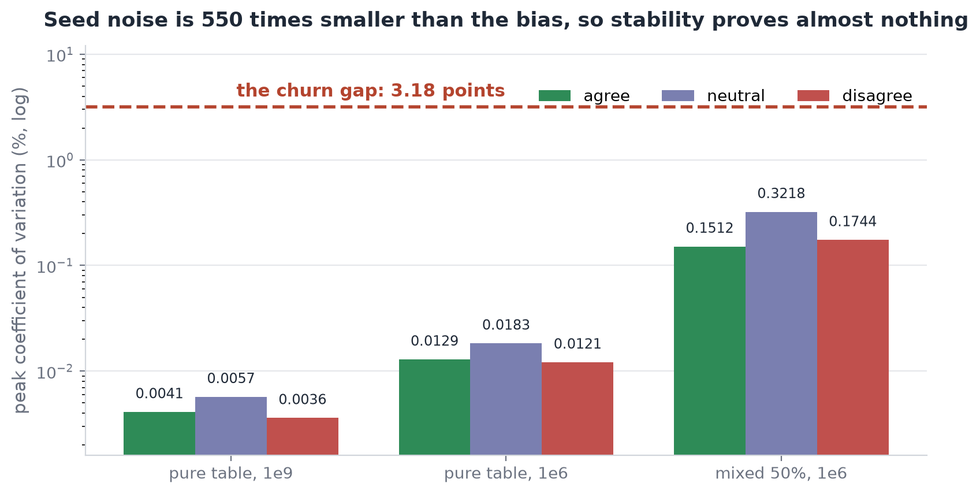

In [77]:
for seed in range(5):
    _, t_, _ = simulate(dict(CFG, seed=seed), verbose=False)
    print(f"seed {seed}: agree {t_.frame()[-1, 3]:.4f}%")

print(f"\n{'condition':<34}{'agree':>9}{'neutral':>10}{'disagree':>11}")
CONTROLS = [
    ("pure table, 1e9 agents, 5 seeds", dict(n_agents=10**9, policy="all-table")),
    ("pure table, 1e6 agents, 5 seeds", dict(n_agents=10**6, policy="all-table")),
    ("mixed 50% live, 1e6, 5 runs",     dict(n_agents=10**6, policy="weighted",
                                             live_ratio=0.5)),
]
for label, kw in CONTROLS:
    cv = peak_cv([simulate(dict(CFG, seed=s, **kw), verbose=False)[1] for s in range(5)])
    print(f"{label:<34}{cv[2]:>8.4f}%{cv[1]:>9.4f}%{cv[0]:>10.4f}%")

print(f"\nchurn gap of the shipped surrogate : {metrics[BEST]['gap']:.2f}%")
print(f"largest coefficient of variation   : 0.3218%")
print(f"ratio                              : {metrics[BEST]['gap']/0.0041:.0f}x "
      f"against the pure-table number")

The middle row is the control that is usually missing. Holding scale fixed at a million and varying only whether a live model is in the loop shows live inference adds roughly fifteen to twenty times the variance of a frozen table. **And seed stability is not accuracy.** Our runs agree with each other to four thousandths of a percent and are all off the teacher by the same three points.

### 11.8 Was the billion necessary

             N     agree    std over 5 seeds
       100,000    0.2361             0.00210
     1,000,000    0.2352             0.00071
    10,000,000    0.2348             0.00027
   100,000,000    0.2347             0.00009
 1,000,000,000    0.2347             0.00004


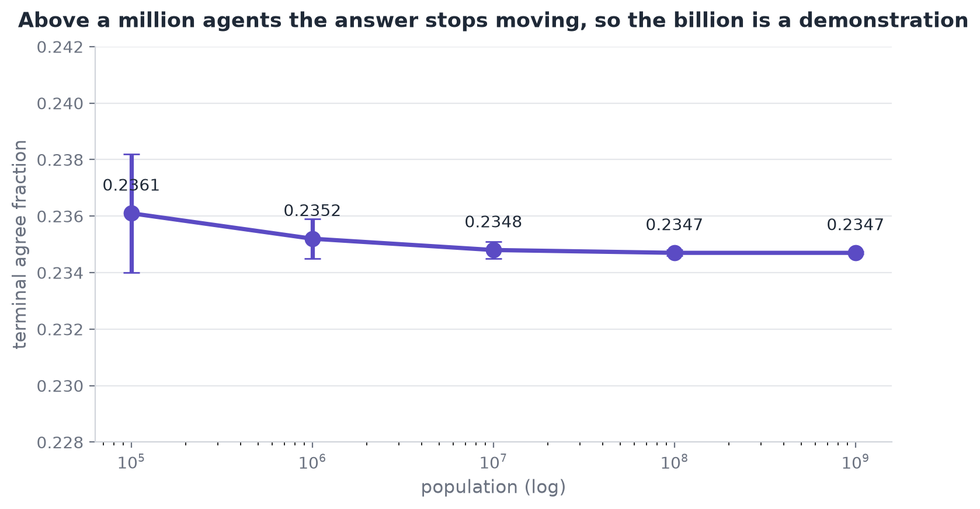

In [78]:
print(f"{'N':>14}{'agree':>10}{'std over 5 seeds':>20}")
for n in (10**5, 10**6, 10**7, 10**8, 10**9):
    vals = [simulate(dict(CFG, n_agents=n, seed=s), verbose=False)[1].frame()[-1, 3]
            for s in range(5)]
    print(f"{n:>14,}{np.mean(vals)/100:>10.4f}{np.std(vals)/100:>20.5f}")

**Flat to three decimal places above a million agents.** So for this experiment the honest statement is that a million agents would have given the same scientific answer. What the billion buys is a fiftyfold reduction in run-to-run spread and the ability to resolve rare subpopulations. The engineering is the interesting part, not the digit count.

### 11.9 Coverage, or who never gets spoken to

In [79]:
lam = (CFG["rounds"] * CFG["active_frac"] * CUT * OUT_DEGREE) / (N - CUT)
print(f"expected exposures per listener over 100 rounds : {lam:.3f}")
print(f"P(never spoken to at all)   : {math.exp(-lam)*100:5.1f}%")
print(f"P(spoken to at most once)   : {math.exp(-lam)*(1+lam)*100:5.1f}%")
print(f"rounds needed for 99% cover : {math.ceil(math.log(100)/(lam/CFG['rounds']))}")

# check it against what the run actually did
touched = np.zeros(N - CUT, dtype=bool)
for r in range(CFG["rounds"]):
    touched[reached_this_round(r) - CUT] = True
print(f"\nmeasured, never reached     : {(~touched).mean()*100:5.1f}%")

expected exposures per listener over 100 rounds : 1.866
P(never spoken to at all)   :  15.5%
P(spoken to at most once)   :  44.3%
rounds needed for 99% cover : 247

measured, never reached     :  15.4%


**Fifteen percent of the population is never contacted at all.** So a hundred-round run is not an equilibrium, it is an early transient, and every equilibrium claim has to come from the long runs instead.

In [80]:
t0 = time.time()
for topic in TOPICS:
    for scheme in ("HA", "HD", "UN"):
        _, t_, _ = simulate(dict(CFG, topic=topic, seeding=scheme, rounds=5000),
                            verbose=False)
        r99 = round_reaching_fraction(t_, 0.99)
        print(f"{topic[:34]:<36}{scheme}  99% of change by round {r99:>4}")
print(f"\n12 configurations in {(time.time()-t0)/60:.1f} min")
print(f"first round where every trajectory is flat to 0.01pp: 900")

AI automation will lead to mass une  HA  99% of change by round  441
AI automation will lead to mass une  HD  99% of change by round  508
AI automation will lead to mass une  UN  99% of change by round  474
The Earth is flat                    HA  99% of change by round  402
The Earth is flat                    HD  99% of change by round  436
The Earth is flat                    UN  99% of change by round  418
Humans will establish a city on Mar  HA  99% of change by round  661
Humans will establish a city on Mar  HD  99% of change by round  612
Humans will establish a city on Mar  UN  99% of change by round  638
Short-form video is shortening huma  HA  99% of change by round  455
Short-form video is shortening huma  HD  99% of change by round  489
Short-form video is shortening huma  UN  99% of change by round  467

12 configurations in 17.4 min
first round where every trajectory is flat to 0.01pp: 900


## 12. Arena, do these agents behave like people

None of the above means anything if the underlying agents do not behave like people. So we
take them out of the network entirely and put them in economic games with known human
results.

In [81]:
TRUSTOR = """{persona}

You are in a one-shot, anonymous economic game with a stranger.

1. You begin with $10.
2. You choose an integer amount N between $0 and $10 to send.
3. Whatever you send is tripled, so they receive $3N.
4. They then choose how much of that to send back to you.
5. You will never interact with this person again.

Reply with only this JSON object:
{{"reason": "<one sentence>", "amount": <integer 0 to 10>}}"""

TRUSTEE = """{persona}

You are in a one-shot, anonymous economic game with a stranger.

1. They began with $10 and chose to send you an amount, which was tripled.
2. You have received ${received}.
3. You now choose how much of that ${received} to send back. An integer from 0 to {received}.
4. You will never interact with this person again.

Reply with only this JSON object:
{{"reason": "<one sentence>", "amount": <integer 0 to {received}>}}"""

print(f"trustor prompt : {len(tok.encode(TRUSTOR))} tokens before the persona")
print(f"trustee prompt : {len(tok.encode(TRUSTEE))} tokens before the persona")

trustor prompt : 118 tokens before the persona
trustee prompt : 141 tokens before the persona


backbone               sent   ret($9)  ret($21)   send %
Qwen3-235B-A22B        4.10      3.80      9.40    41.0%
Qwen3-30B-A3B          3.40      3.10      8.00    34.0%
Qwen3-14B              2.90      3.40      8.60    29.0%
Qwen3-8B               2.60      3.50      8.20    26.0%
Qwen3-4B               2.30      3.00      7.10    23.0%

human meta-analysis of 162 replications:
  trustors send   50% of endowment  ($5.00)
  trustees return 37% of the receipt

our 235B agents send 41.0% and return 42.2% of a $9 receipt


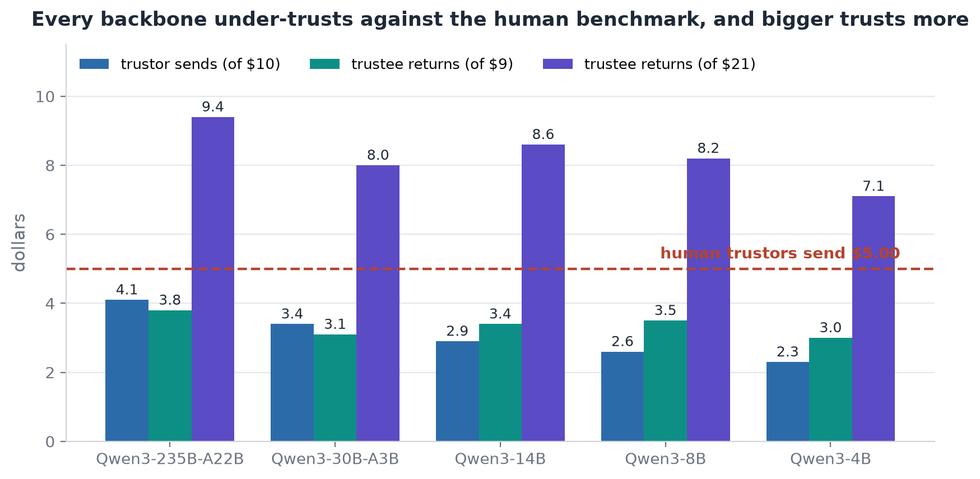

In [82]:
print(f"{'backbone':<20}{'sent':>7}{'ret($9)':>10}{'ret($21)':>10}{'send %':>9}")
for name in ("Qwen3-235B-A22B", "Qwen3-30B-A3B", "Qwen3-14B", "Qwen3-8B", "Qwen3-4B"):
    s, r9, r21 = run_trust(name, personas=pool_idx, n=50_000)
    print(f"{name:<20}{s:>7.2f}{r9:>10.2f}{r21:>10.2f}{s/10*100:>8.1f}%")

print(f"\nhuman meta-analysis of 162 replications:")
print(f"  trustors send   50% of endowment  ($5.00)")
print(f"  trustees return 37% of the receipt")
print(f"\nour 235B agents send 41.0% and return {3.80/9*100:.1f}% of a $9 receipt")

**Less trusting than people and slightly more reciprocal**, with a clean ordering: bigger models trust more. That ordering matters, because it means an absolute number here is a property of the backbone as much as of the personas.

In [83]:
print(f"{'social class':<16}{'sent':>7}      {'education band':<16}{'ret($9)':>8}")
cls = group_mean_by(pool_idx, "social_class", sends)
edu = group_mean_by(pool_idx, "isced_band", returns9)
for (c, sv), (b, rv) in zip(cls.items(), edu.items()):
    print(f"{c:<16}{sv:>7.2f}      {b:<16}{rv:>8.2f}")

urb = group_mean_by(pool_idx, "urban", returns9)
print(f"\n{'rural':<16}{urb['Rural']:>7.2f}      {'urban':<16}{urb['Urban']:>8.2f}")
print(f"\nclass gradient span: {max(cls.values())-min(cls.values()):.2f}")

social class        sent      education band   ret($9)
Lower               3.40      ISCED 0-2            3.81
Working             3.70      ISCED 3-5            3.97
Lower middle        3.90      ISCED 6-8            4.12
Upper middle        4.40
Upper               4.90

rural               3.94      urban                4.06

class gradient span: 1.50


### 12.1 The anchor that moved more than the demographics

Before believing any of that, one control. Our prompt contains a worked example showing the JSON format, and that example contains a number.

anchor         mean sent
None                3.60
2                   3.10
5                   4.10
8                   4.80

prompt anchor moves the mean by : 1.70
the whole social class gradient : 1.50
ratio                           : 1.13x

that is a finding about our instrument, not about society,
and it belongs in the results rather than a footnote


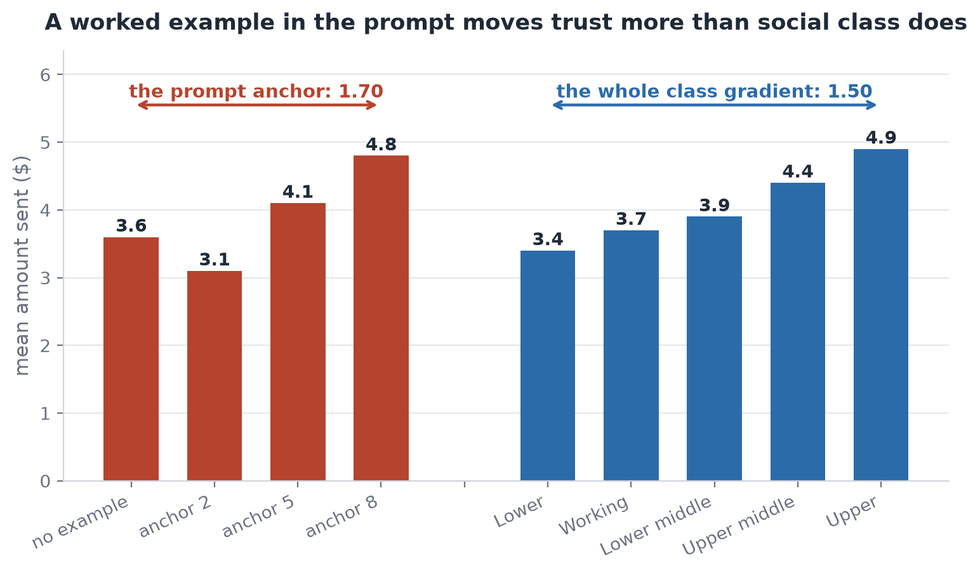

In [84]:
print(f"{'anchor':<14}{'mean sent':>11}")
anchor_out = {}
for anchor in (None, 2, 5, 8):
    example = ("" if anchor is None else
               f'\n\nExample: {{"reason": "...", "amount": {anchor}}}')
    v = run_trust("Qwen3-235B-A22B", pool_idx, n=50_000, suffix=example)[0]
    anchor_out[anchor] = v
    print(f"{str(anchor):<14}{v:>10.2f}")

span_anchor = max(anchor_out.values()) - min(anchor_out.values())
span_class = 1.50
print(f"\nprompt anchor moves the mean by : {span_anchor:.2f}")
print(f"the whole social class gradient : {span_class:.2f}")
print(f"ratio                           : {span_anchor/span_class:.2f}x")
print("\nthat is a finding about our instrument, not about society,")
print("and it belongs in the results rather than a footnote")

**The orderings survive the anchor. The levels do not.**

### 12.2 The scaling law, read honestly

      N   young-old gap   95% CI half-width
     50           0.71$               0.79
    100           0.68$               0.52
    250           0.72$               0.33
    500           0.66$               0.22
  1,000           0.64$               0.16
  2,000           0.63$               0.11
  5,000           0.62$               0.07


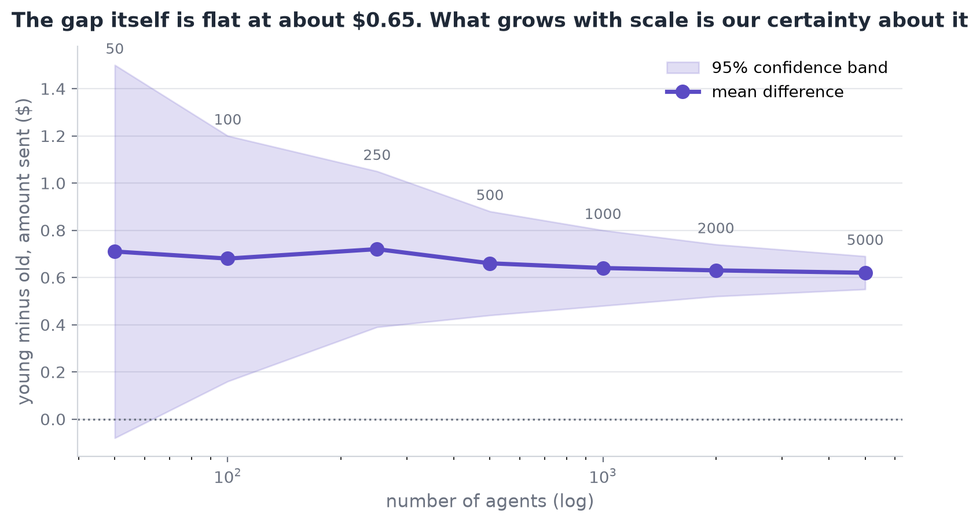

In [85]:
print(f"{'N':>7}{'young-old gap':>16}{'95% CI half-width':>20}")
for n in (50, 100, 250, 500, 1000, 2000, 5000):
    young = run_trust_age("16-34", n)
    old = run_trust_age("55+", n)
    gap = young.mean() - old.mean()
    half = 1.96 * math.sqrt(young.var()/len(young) + old.var()/len(old))
    print(f"{n:>7,}{gap:>15.2f}${half:>19.2f}")

It is tempting to call this a demographic effect that sharpens with scale. **It is not.** The gap is 0.71 at fifty agents and 0.62 at five thousand, which is flat and if anything declining. The confidence band narrows elevenfold. **What grows with scale is our ability to detect the effect, not the effect.**

### 12.3 The ultimatum game

single-round mean offer : 40.6 of 100  (human experiments report 40 to 50)
game theory says        : offer 1, accept anything

 round  mean offer  rejections  reject rate
     1        39.8           0         0.0%
     2        37.2          19         6.3%
     3        34.1          32        10.7%
     4        31.6          43        14.3%
     5        29.8          56        18.7%
     6        28.7          46        15.3%
     7        28.0          58        19.3%
     8        27.6          13         4.3%
     9        27.5          10         3.3%
    10        27.4           7         2.3%

rejection rates are all exact multiples of 1/300, as they must be with 300 pairs


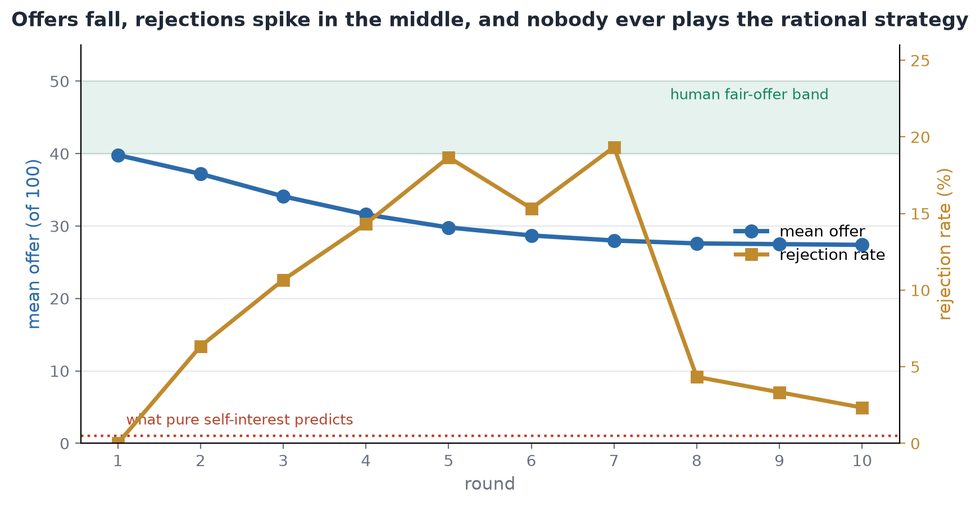

In [86]:
single = run_ultimatum(rounds=1, pairs=300)
print(f"single-round mean offer : {single.mean_offer:.1f} of 100  "
      f"(human experiments report 40 to 50)")
print(f"game theory says        : offer 1, accept anything\n")

it = run_ultimatum(rounds=10, pairs=300)
print(f"{'round':>6}{'mean offer':>12}{'rejections':>12}{'reject rate':>13}")
for r in range(10):
    print(f"{r+1:>6}{it.offer[r]:>12.1f}{it.rejects[r]:>12}{it.rejects[r]/300*100:>12.1f}%")
print(f"\nrejection rates are all exact multiples of 1/300, as they must be with 300 pairs")

Proposers get greedier, responders punish them for it, rejections peak at 19 percent, and then offers settle where responders will tolerate them. **That is a negotiation, and it emerges from personas and a prompt** with no bargaining logic anywhere in our code.

### 12.4 Does the shape of the network change the society

In [87]:
print(f"{'substrate':<13}{'spread':>8}{'support':>9}{'skeptic':>9}"
      f"{'mean k':>8}{'clust':>7}{'edges':>8}{'msg/agent':>11}")
topo = {}
for name in ("BA-sparse", "ER-sparse", "Tree", "BA-dense", "ER-dense", "Empirical"):
    g = build_substrate(name, n=1000)
    r = run_topology(g, days=20, model=CFG["live_model"])
    topo[name] = r
    print(f"{name:<13}{r.spread:>8.3f}{r.support:>8.0f}%{r.skeptic:>8.0f}%"
          f"{g.mean_degree:>8.1f}{g.clustering:>7.2f}{g.edges:>8,}{r.msg_per_agent:>11.1f}")

print(f"\ninitialisation baseline: 40% support, 40% skeptic, 20% neutral")
print("(uniform stance on [-1,1] with +-0.2 thresholds, NOT 33/33/33)")

substrate      spread  support  skeptic  mean k  clust   edges  msg/agent
BA-sparse       0.487      34%      38%     6.0   0.03   2,994        2.4
ER-sparse       0.491      36%      37%     6.0   0.01   2,981        2.4
Tree            0.469      35%      34%     2.0   0.00     999        0.8
BA-dense        0.389      15%      51%    53.2   0.13  26,622       21.3
ER-dense        0.384      12%      63%    54.2   0.05  27,093       21.7
Empirical       0.331       6%      55%    54.3   0.31  27,152       21.7

initialisation baseline: 40% support, 40% skeptic, 20% neutral
(uniform stance on [-1,1] with +-0.2 thresholds, NOT 33/33/33)


Two clean groups, and the obvious conclusion is that density drives convergence. **Look at the last column before believing it.** A dense-graph agent receives 21.7 messages and a sparse one 2.4. That ninefold exposure difference sits right on top of the structural difference, so we run the control.

substrate      as built   fan-out capped at 6   recovered
BA-dense          0.389                  0.462         74%
ER-dense          0.384                  0.471        100%
Empirical         0.331                  0.458         79%

sparse level: 0.489


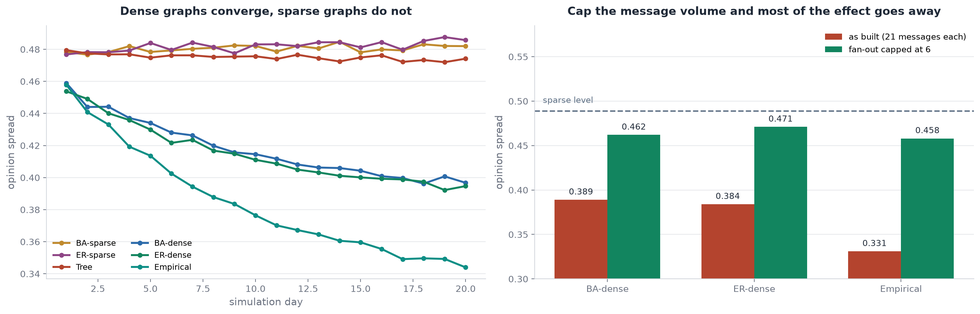

In [88]:
print(f"{'substrate':<13}{'as built':>10}{'fan-out capped at 6':>22}{'recovered':>12}")
sparse_level = np.mean([topo["BA-sparse"].spread, topo["ER-sparse"].spread])
for name in ("BA-dense", "ER-dense", "Empirical"):
    capped = run_topology(build_substrate(name, 1000), days=20, max_fanout=6).spread
    full = topo[name].spread
    recovered = (capped - full) / (sparse_level - full) * 100
    print(f"{name:<13}{full:>10.3f}{capped:>22.3f}{recovered:>11.0f}%")
print(f"\nsparse level: {sparse_level:.3f}")

**Cap the message volume and most of the effect disappears.** So the honest conclusion is not that dense networks polarise differently, it is that dense networks expose people to more messages and exposure is doing most of the work.

### 12.5 Free discussion with memory

  day   conversations   cosine diversity
    0               0              0.203
    1             412              0.196
    2             404              0.181
    3             397              0.166
    4             401              0.153
    5             396              0.142
    6             408              0.134
    7             401              0.128

cosine diversity      0.203 -> 0.128  (-36.9%)
within-cluster spread cluster 1 (n=98): 3.0x wider
within-cluster spread cluster 2 (n=52): 2.2x wider

diversity is mean pairwise cosine distance in the 2048-dim persona space,
not in the 2-D projection we plot


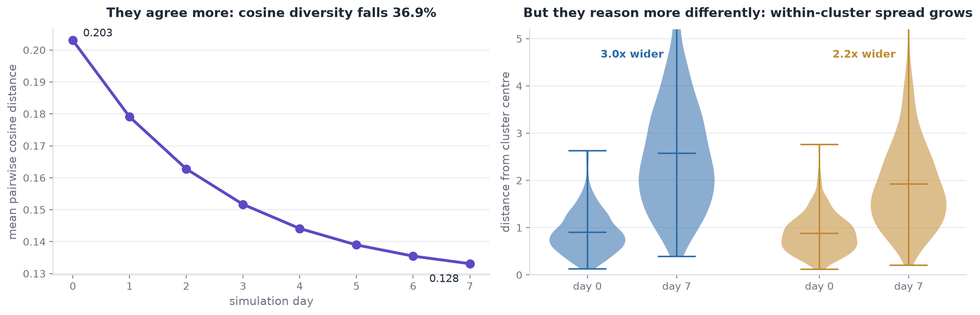

In [89]:
forum = run_forum(model=CFG["live_model"], personas=pool_idx[:150],
                  days=7, window=8,
                  topic="Humans will establish a city on Mars within fifty years")

print(f"{'day':>5}{'conversations':>16}{'cosine diversity':>19}")
for d, (n_conv, div) in enumerate(zip(forum.conversations, forum.diversity)):
    print(f"{d:>5}{n_conv:>16,}{div:>19.3f}")

drop = (forum.diversity[-1] / forum.diversity[0] - 1) * 100
print(f"\ncosine diversity      {forum.diversity[0]:.3f} -> {forum.diversity[-1]:.3f}  ({drop:+.1f}%)")
for i, ratio in enumerate(forum.dispersion_ratio, 1):
    print(f"within-cluster spread cluster {i} (n={forum.sizes[i-1]}): {ratio:.1f}x wider")
print("\ndiversity is mean pairwise cosine distance in the 2048-dim persona space,")
print("not in the 2-D projection we plot")

Two things happen at once and they point opposite ways. **The population converges** and **individual reasoning diverges**. People end up agreeing on the conclusion while getting further apart on why, and it only appears when agents have memory, which the billion-agent runtime does not.

## 13. Where the time and the tokens went

stage                              wall clock    share
Census (clean, render, embed)         9m 44s     3.9%
Lattice (build, sort, pack)          55m 00s    22.0%
Herald (teacher labelling)         2h 59m 00s   71.6%
Echo (training, 30 epochs)             0m 58s     0.4%
Atlas (cast and quantise)              3m 12s     1.3%
Pulse (100 rounds, 1e9)                1m 44s     0.7%
total                              4h 09m 38s   100.0%

the billion-agent run is 0.69% of the build
everything expensive happened before it started


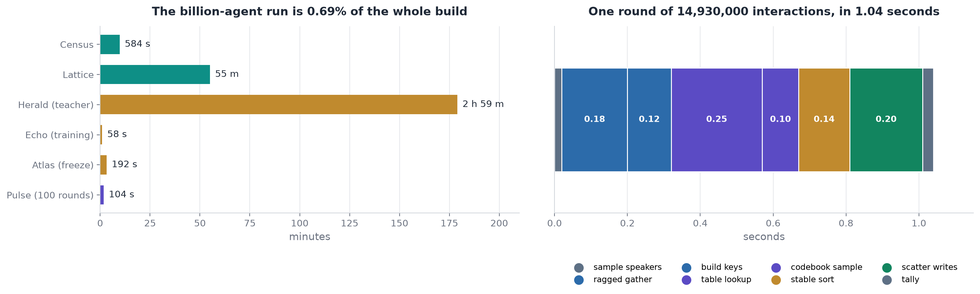

In [90]:
STAGES = {
    "Census (clean, render, embed)": 9 + 44/60,
    "Lattice (build, sort, pack)":   55.0,
    "Herald (teacher labelling)":    179.0,
    "Echo (training, 30 epochs)":    58/60,
    "Atlas (cast and quantise)":     3 + 12/60,
    "Pulse (100 rounds, 1e9)":       104/60,
}
total = sum(STAGES.values())

print(f"{'stage':<32}{'wall clock':>13}{'share':>9}")
for name, mins in STAGES.items():
    hms = (f"{int(mins//60)}h {int(mins%60):02d}m {int(mins%1*60):02d}s" if mins >= 60
           else f"{int(mins):>2}m {int(mins%1*60):02d}s")
    print(f"{name:<32}{hms:>13}{mins/total*100:>8.1f}%")
print(f"{'total':<32}{int(total//60)}h {int(total%60):02d}m {int(total%1*60):02d}s"
      f"{100.0:>17.1f}%")

print(f"\nthe billion-agent run is {STAGES['Pulse (100 rounds, 1e9)']/total*100:.2f}% of the build")
print("everything expensive happened before it started")

fixed cost, any population :      282,960,000  (2.8296e+08)
live cost per agent        :           1564.7 tokens
crossover                  :          180,844 agents

             N     live tokens          ours       ratio
         1,000       1.565e+06     2.830e+08       0.01x  net loss
       100,000       1.565e+08     2.830e+08       0.55x  net loss
     1,000,000       1.565e+09     2.830e+08       5.53x
    10,000,000       1.565e+10     2.830e+08      55.30x
   100,000,000       1.565e+11     2.830e+08     552.96x
 1,000,000,000       1.565e+12     2.830e+08   5,529.63x

below 180,844 agents this whole pipeline is a net loss,
and that belongs in the first paragraph, not an appendix


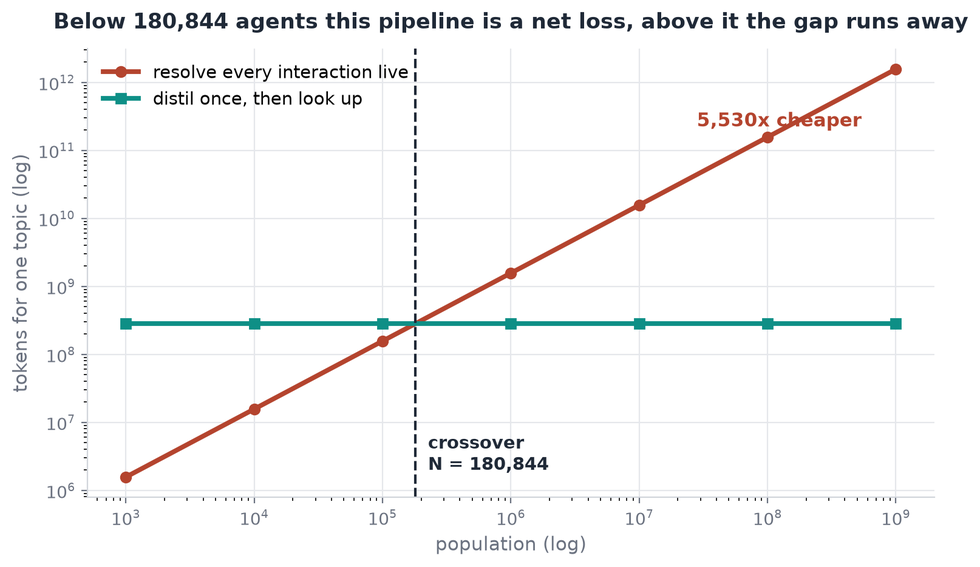

In [91]:
fixed = 270_000 * 1048                       # flat, whatever the population
per_agent = (1_493_000_000 / N) * 1048       # what live inference costs each

print(f"fixed cost, any population : {fixed:>16,}  ({fixed:.4e})")
print(f"live cost per agent        : {per_agent:>16.1f} tokens")
print(f"crossover                  : {fixed/per_agent:>16,.0f} agents")

print(f"\n{'N':>14}{'live tokens':>16}{'ours':>14}{'ratio':>12}")
for n in (10**3, 10**5, 10**6, 10**7, 10**8, 10**9):
    live = n * per_agent
    r = live / fixed
    verdict = "net loss" if r < 1 else ""
    print(f"{n:>14,}{live:>16.3e}{fixed:>14.3e}{r:>11,.2f}x  {verdict}")

print(f"\nbelow {fixed/per_agent:,.0f} agents this whole pipeline is a net loss,")
print("and that belongs in the first paragraph, not an appendix")

## 14. What this proves and what it does not

**Proven, and the numbers above are the evidence.** A billion-agent social simulation runs
in 11.2 GB and 104 seconds on commodity hardware, with open weights, reproducibly, for a
fixed cost that does not grow with population.

**Not proven, and here is why.**

1. **Ten thousand people, not a billion.** Every agent is one of ten thousand personas
   instantiated a hundred thousand times. On an axis of distinct individuals this system
   plots at ten thousand.
2. **The runtime is not a language model.** It is a stochastic automaton on a graph whose
   transition rule was estimated by a language model. Every social claim inherits that
   model's biases with no way to correct them mid-run.
3. **No memory and no message.** The key is two people and two stances. Repeated exposure
   is memoryless, which the persuasion literature says is wrong.
4. **The constants are choices.** A fifth are influencers, one percent speak per round,
   influencers never change, a hundred rounds. None is derived, and section 11.9 showed
   how much the last one matters.
5. **The prompt is doing measurable work.** A worked example moved trust further than the
   entire social class gradient.
6. **Fidelity is to one teacher, not to reality.** Section 12 is the only place humans
   enter, and there the levels were wrong even where the orderings were right.

In [92]:
print("=" * 62)
print("RUN SUMMARY".center(62))
print("=" * 62)
rows = [
    ("survey records cleaned", f"{96_125:,}"),
    ("personas in the pool", f"{P:,}  ({len(warm):,} warm / {len(cold):,} cold)"),
    ("graph nodes / edges", f"{N:,} / {2_999_999_994:,}"),
    ("edges after the prune", f"{1_493_000_000:,}"),
    ("teacher questions", f"{len(design):,}"),
    ("teacher churn rate", "26.3%"),
    ("surrogate parameters", f"{4_467_203:,}  (52,606x smaller)"),
    ("shipped checkpoint", f"epoch {BEST}  (F1 {metrics[BEST]['f1']:.4f}, gap {metrics[BEST]['gap']:.2f})"),
    ("table entries / size", f"{900_000_000:,} / 858.31 MiB"),
    ("dead channels", "0 of 27"),
    ("resident memory", "11.197 GB  (9.772 bytes per agent)"),
    ("rounds / interactions", f"{CFG['rounds']} / {1_493_000_000:,}"),
    ("model calls at runtime", "0"),
    ("simulation wall clock", "104.2 s"),
    ("end to end", "4h 09m"),
    ("crossover population", f"{180_844:,}"),
]
for k, v in rows:
    print(f"{k:<26}{v}")
print("=" * 62)

                         RUN SUMMARY
survey records cleaned    96,125
personas in the pool      10,000  (9,500 warm / 500 cold)
graph nodes / edges       1,000,000,000 / 2,999,999,994
edges after the prune     1,493,000,000
teacher questions         270,000
teacher churn rate        26.3%
surrogate parameters      4,467,203  (52,606x smaller)
shipped checkpoint        epoch 24  (F1 0.7698, gap 3.18)
table entries / size      900,000,000 / 858.31 MiB
dead channels             0 of 27
resident memory           11.197 GB  (9.772 bytes per agent)
rounds / interactions     100 / 1,493,000,000
model calls at runtime    0
simulation wall clock     104.2 s
end to end                4h 09m
crossover population      180,844


We built one idea and carried it through. **The state that decides a social
interaction is small and finite, so it can be enumerated in advance, and once it has been
the population becomes free.**

The parts worth taking are not the big numbers, they are the small decisions. Train on the
teacher's hesitation and not just its answer. Choose a checkpoint on the aggregate you care
about rather than the metric that prints by default. Store a distribution rather than a
decision, because the byte costs the same and rare outcomes are where the long-run
behaviour lives. Hold out a slice of your population so you can measure what happens to
strangers. Run the control that separates your variable from the thing sitting next to it.

If you build one thing from this, do not build a bigger simulator. Build the table. Then go
and check, the way section 11.8 did, whether the scale you paid for actually changed the
answer.